In [1]:
import wandb
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from typing import Any, Callable, Mapping, Optional, Text, Tuple, Union, Iterable
import numpy as np
import plotly.graph_objects as go
from absl import logging
import utils
import hydra

# plt.style.use('default')
sns.set_theme()


In [2]:
import torch
import wandb
from dm_env import specs

import dmc
import utils
import uuid
from logger import Logger
from replay_buffer import ReplayBufferStorage, make_replay_loader

from video import TrainVideoRecorder, VideoRecorder
from collections import OrderedDict

from modulators import NoisySineModulator
from scipy.integrate import trapezoid

You are using a GLFW raw input patch. This is not the official GLFW library.


/opt/homebrew/Caskroom/miniforge/base/envs/mini_env311/lib/python3.11/site-packages/torchvision/io/image.py:14: UserWarning: Failed to load image Python extension: 'dlopen(/opt/homebrew/Caskroom/miniforge/base/envs/mini_env311/lib/python3.11/site-packages/torchvision/image.so, 0x0006): Library not loaded: @rpath/libjpeg.9.dylib
  Referenced from: <EB3FF92A-5EB1-3EE8-AF8B-5923C1265422> /opt/homebrew/Caskroom/miniforge/base/envs/mini_env311/lib/python3.11/site-packages/torchvision/image.so
  Reason: tried: '/opt/homebrew/Caskroom/miniforge/base/envs/mini_env311/lib/python3.11/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/opt/homebrew/Caskroom/miniforge/base/envs/mini_env311/lib/python3.11/site-packages/torchvision/../../../libjpeg.9.dylib' (no such file), '/opt/homebrew/Caskroom/miniforge/base/envs/mini_env311/lib/python3.11/lib-dynload/../../libjpeg.9.dylib' (no such file), '/opt/homebrew/Caskroom/miniforge/base/envs/mini_env311/bin/../lib/libjpeg.9.dylib' (no su

In [3]:
from hydra.core.global_hydra import GlobalHydra
from omegaconf import DictConfig, OmegaConf

# Clear existing Hydra instance if already initialized
if GlobalHydra.instance().is_initialized():
    GlobalHydra.instance().clear()

# Initialize Hydra and load the config directly
hydra.initialize(config_path="./", version_base=None)
cfg = hydra.compose(config_name="full_train_multitimescale")

In [4]:
domain = "humanoid"

In [5]:
from dmc_benchmark import (
    PRIMAL_TASKS,
    PRIMAL_TASKS_WALK,
    PRIMAL_TASKS_FAST_RUN,
    PRIMAL_TASKS_RUN_BACKWARD,
    CRL_TASKS_SAME_REWARD,
    CRL_TASKS_DIFF_REWARD,
    CRL_DIFF_DYNAMICS_DIFF_REWARD,
    CRL_TASKS_DIFF_RUN_SPEED_REWARD,
    CRL_DIFF_DOMAINS_SAME_REWARD,
    CRL_WALKER_WALK_RUN_TASKS,
    CRL_WALKER_STAND_RUN_TASKS,
    CRL_RUN_JUMP_TASKS,
    CRL_DIFF_DOMAINS_DIFF_REWARD,
    CRL_DIFF_DOMAINS_DIFF_REWARD_CHEETAH_FISH,
)

num_actions = {
    "cheetah": 6,
    "walker": 6,
    "quadruped": 12,
    "cartpole": 1,
    "humanoid": 21,
    "fish": 5,
    "dog": 38,
    "finger": 2,
}

In [6]:
switch_mass_friction_every_n_episodes = 10
mass_modulator_period = 250000
friction_modulator_period = 500000

percentage_shifts_mass = {
    "walker": 0.05,
    "cheetah": 0.05,
    "quadruped": 0.8,
    "humanoid": 0.1,
}
percentage_shifts_friction = {
    "walker": 0,
    "cheetah": 0,
    "quadruped": 0,
    "humanoid": 0,
}

In [7]:
api = wandb.Api()
project_name = "continual_rl" + domain + "_" + cfg.mode
entity = "crlmsf"
runs = api.runs(entity + "/" + project_name)

summary_list, config_list, name_list = [], [], []

logging.info("inside avg_episode_return")

num_of_runs = len(runs)
print("num_of_runs:", num_of_runs)

num_points_per_task = cfg.num_train_frames / cfg.eval_every_frames
# num_data_points_trained = (
#     num_points_per_task * cfg.num_unique_tasks * cfg.train.num_exposures
# )
# num_data_points_plotting = (
#     num_points_per_task * cfg.num_unique_tasks * cfg.num_exposures
# )

# print("num_data_points_trained: ", num_data_points_trained)
# print("num_data_points_plotting: ", num_data_points_plotting)

for idx, run in enumerate(runs):
    # .summary contains the output keys/values
    #  for metrics such as accuracy.
    #  We call ._json_dict to omit large files
    # summary_list.append(run.summary._json_dict)
    if idx % 10 == 0:
        print("idx:", idx)

    if "best" not in run.tags:
        continue

    if run.config["percentage_shifts_mass"] != percentage_shifts_mass[domain]:
        continue

    print(run.config["agent_name"])

    avg_episode_returns_history = run.scan_history(keys=["eval/episode_reward"])
    avg_episode_reward = [
        row["eval/episode_reward"] for row in avg_episode_returns_history
    ]

    # train_avg_episode_returns_history = run.scan_history(keys=["train/episode_reward"])
    # train_avg_episode_reward = [
    #     row["train/episode_reward"] for row in train_avg_episode_returns_history
    # ]

    steps_history = run.scan_history(keys=["eval/step"])

    steps = [row["eval/step"] for row in steps_history]

    # update_steps_history = run.scan_history(keys=["train/update_step"])
    # update_steps = [row["train/update_step"] for row in update_steps_history]

    # if len(steps) < num_data_points_plotting:
    #     print("len(steps) < num_data_points_plotting")
    #     print("seed: ", run.config["agents_seed"])
    #     print("agent_name: ", run.config["agent_name"])
    #     continue




    print("len(steps): ", len(steps))
    print("len(avg_episode_reward): ", len(avg_episode_reward))

    # print("len(update_steps): ", len(update_steps))
    # print("len(train_avg_episode_reward: ", len(train_avg_episode_reward))
    # print("len(train_avg_episode_reward): ", len(train_avg_episode_reward))
    #
    # print(update_steps[0])
    # print(train_avg_episode_reward[0])

    # combine steps and avg_episode_returns into a dictionary using train/steps and train/avg_episode_returns
    # as the keys.
    temp = dict()
    temp["eval/step"] = steps
    # temp["train/update_step"] = update_steps
    temp["eval/episode_reward"] = avg_episode_reward
    # temp["train/episode_reward"] = train_avg_episode_reward

    if "attention" in run.config["agent_name"]:
        #attention 1
        # attention_7_history_1 = run.scan_history(keys=["train/attention_distribution1_u_7_mean"])
        # attention_7_1 = [row["train/attention_distribution1_u_7_mean"] for row in attention_7_history_1]
        #
        # attention_6_history_1 = run.scan_history(keys=["train/attention_distribution1_u_6_mean"])
        # attention_6_1 = [row["train/attention_distribution1_u_6_mean"] for row in attention_6_history_1]
        #
        # attention_5_history_1 = run.scan_history(keys=["train/attention_distribution1_u_5_mean"])
        # attention_5_1 = [row["train/attention_distribution1_u_5_mean"] for row in attention_5_history_1]
        #
        # attention_4_history_1 = run.scan_history(keys=["train/attention_distribution1_u_4_mean"])
        # attention_4_1 = [row["train/attention_distribution1_u_4_mean"] for row in attention_4_history_1]

        attention_3_history_1 = run.scan_history(keys=["train/attention_distribution1_u_3_mean"])
        attention_3_1 = [row["train/attention_distribution1_u_3_mean"] for row in attention_3_history_1]

        attention_2_history_1 = run.scan_history(keys=["train/attention_distribution1_u_2_mean"])
        attention_2_1 = [row["train/attention_distribution1_u_2_mean"] for row in attention_2_history_1]

        attention_1_history_1 = run.scan_history(keys=["train/attention_distribution1_u_1_mean"])
        attention_1_1 = [row["train/attention_distribution1_u_1_mean"] for row in attention_1_history_1]

        attention_0_history_1 = run.scan_history(keys=["train/attention_distribution1_u_0_mean"])
        attention_0_1 = [row["train/attention_distribution1_u_0_mean"] for row in attention_0_history_1]

        #attention 2
        # attention_7_history_2 = run.scan_history(keys=["train/attention_distribution2_u_7_mean"])
        # attention_7_2 = [row["train/attention_distribution2_u_7_mean"] for row in attention_7_history_2]
        #
        # attention_6_history_2 = run.scan_history(keys=["train/attention_distribution2_u_6_mean"])
        # attention_6_2 = [row["train/attention_distribution2_u_6_mean"] for row in attention_6_history_2]
        #
        # attention_5_history_2 = run.scan_history(keys=["train/attention_distribution2_u_5_mean"])
        # attention_5_2 = [row["train/attention_distribution2_u_5_mean"] for row in attention_5_history_2]
        #
        # attention_4_history_2 = run.scan_history(keys=["train/attention_distribution2_u_4_mean"])
        # attention_4_2 = [row["train/attention_distribution2_u_4_mean"] for row in attention_4_history_2]

        attention_3_history_2 = run.scan_history(keys=["train/attention_distribution2_u_3_mean"])
        attention_3_2 = [row["train/attention_distribution2_u_3_mean"] for row in attention_3_history_2]

        attention_2_history_2 = run.scan_history(keys=["train/attention_distribution2_u_2_mean"])
        attention_2_2 = [row["train/attention_distribution2_u_2_mean"] for row in attention_2_history_2]

        attention_1_history_2 = run.scan_history(keys=["train/attention_distribution2_u_1_mean"])
        attention_1_2 = [row["train/attention_distribution2_u_1_mean"] for row in attention_1_history_2]

        attention_0_history_2 = run.scan_history(keys=["train/attention_distribution2_u_0_mean"])
        attention_0_2 = [row["train/attention_distribution2_u_0_mean"] for row in attention_0_history_2]

        # attention_7_1.insert(0, 0)
        # attention_6_1.insert(0, 0)
        # attention_5_1.insert(0, 0)
        # attention_4_1.insert(0, 0)
        attention_3_1.insert(0, 0)
        attention_2_1.insert(0, 0)
        attention_1_1.insert(0, 0)
        attention_0_1.insert(0, 0)

        # attention_7_2.insert(0, 0)
        # attention_6_2.insert(0, 0)
        # attention_5_2.insert(0, 0)
        # attention_4_2.insert(0, 0)
        attention_3_2.insert(0, 0)
        attention_2_2.insert(0, 0)
        attention_1_2.insert(0, 0)
        attention_0_2.insert(0, 0)

        # temp["train/attention_distribution1_u_7_mean"] = attention_7_1
        # temp["train/attention_distribution1_u_6_mean"] = attention_6_1
        # temp["train/attention_distribution1_u_5_mean"] = attention_5_1
        # temp["train/attention_distribution1_u_4_mean"] = attention_4_1
        temp["train/attention_distribution1_u_3_mean"] = attention_3_1
        temp["train/attention_distribution1_u_2_mean"] = attention_2_1
        temp["train/attention_distribution1_u_1_mean"] = attention_1_1
        temp["train/attention_distribution1_u_0_mean"] = attention_0_1

        # temp["train/attention_distribution2_u_7_mean"] = attention_7_2
        # temp["train/attention_distribution2_u_6_mean"] = attention_6_2
        # temp["train/attention_distribution2_u_5_mean"] = attention_5_2
        # temp["train/attention_distribution2_u_4_mean"] = attention_4_2
        temp["train/attention_distribution2_u_3_mean"] = attention_3_2
        temp["train/attention_distribution2_u_2_mean"] = attention_2_2
        temp["train/attention_distribution2_u_1_mean"] = attention_1_2
        temp["train/attention_distribution2_u_0_mean"] = attention_0_2

    else:
        zeros_list = [0] * len(steps)
        # temp["train/attention_distribution1_u_7_mean"] = zeros_list
        # temp["train/attention_distribution1_u_6_mean"] = zeros_list
        # temp["train/attention_distribution1_u_5_mean"] = zeros_list
        # temp["train/attention_distribution1_u_4_mean"] = zeros_list
        temp["train/attention_distribution1_u_3_mean"] = zeros_list
        temp["train/attention_distribution1_u_2_mean"] = zeros_list
        temp["train/attention_distribution1_u_1_mean"] = zeros_list
        temp["train/attention_distribution1_u_0_mean"] = zeros_list

        # temp["train/attention_distribution2_u_7_mean"] = zeros_list
        # temp["train/attention_distribution2_u_6_mean"] = zeros_list
        # temp["train/attention_distribution2_u_5_mean"] = zeros_list
        # temp["train/attention_distribution2_u_4_mean"] = zeros_list
        temp["train/attention_distribution2_u_3_mean"] = zeros_list
        temp["train/attention_distribution2_u_2_mean"] = zeros_list
        temp["train/attention_distribution2_u_1_mean"] = zeros_list
        temp["train/attention_distribution2_u_0_mean"] = zeros_list

    print("len attention_0_1: ", len(temp["train/attention_distribution1_u_0_mean"]))

    summary_list.append(temp)
    del temp

    # .config contains the hyperparameters.
    #  We remove special values that start with _.
    config_list.append(
        {k: v for k, v in run.config.items() if not k.startswith("_")}
    )

    # .name is the human-readable name of the run.
    name_list.append(run.name)

num_of_runs: 511
idx: 0
idx: 10
idx: 20
idx: 30
idx: 40
ddpg
len(steps):  300
len(avg_episode_reward):  300
len attention_0_1:  300
ddpg
len(steps):  300
len(avg_episode_reward):  300
len attention_0_1:  300
ddpg
len(steps):  300
len(avg_episode_reward):  300
len attention_0_1:  300
ddpg
len(steps):  300
len(avg_episode_reward):  300
len attention_0_1:  300
ddpg
len(steps):  300
len(avg_episode_reward):  300
len attention_0_1:  300
idx: 50
idx: 60
ddpg_beakers_params_continuous
len(steps):  300
len(avg_episode_reward):  300
len attention_0_1:  300
ddpg_beakers_params_continuous
len(steps):  300
len(avg_episode_reward):  300
len attention_0_1:  300
ddpg_beakers_params_continuous
len(steps):  300
len(avg_episode_reward):  300
len attention_0_1:  300
ddpg_beakers_params_continuous
len(steps):  300
len(avg_episode_reward):  300
len attention_0_1:  300
ddpg_beakers_params_continuous
len(steps):  300
len(avg_episode_reward):  300
len attention_0_1:  300
idx: 70
sf_simple_beakers_params
len(s

In [8]:
runs_df = pd.DataFrame(
        {"summary": summary_list, "config": config_list, "name": name_list}
    )

# create a new column using agent_name
runs_df["agent_name"] = runs_df["config"].apply(lambda x: x["agent_name"])

# # create a new column using agents_seed
runs_df["agent_seed"] = runs_df["config"].apply(lambda x: x["seed"])

In [9]:
agents_new_names = {
    "ddpg": "TD3",
    "ddpg_beakers_params_continuous": "TD3 + SC",
    "sf_simple": "SF",
    "sf_simple_beakers_params": "SF + SC (Ours)",
    "ddpg_plasticity_injection_last_layer": "TD3 + P-last",
    "ddpg_online_ewc": "TD3 + EWC",
    "sf_online_ewc": "SF + EWC",
    "sf_simple_beakers_params_continuous_attention_diff_unique": "SF + SC + Attention (Ours)",
    "ddpg_plasticity_injection": "TD3 + Plasticity (last few layers)",
    "ddpg_continual_backprop": "TD3 + CBP",
    "ppo": "PPO"
}

In [10]:
# replace all "ddpg" in agent_name column with "TD3"
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "ddpg", agents_new_names["ddpg"]
)

In [11]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "sf_simple", agents_new_names["sf_simple"]
)

In [12]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "ddpg_beakers_params_continuous", agents_new_names["ddpg_beakers_params_continuous"]
)

In [13]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "sf_simple_beakers_params", agents_new_names["sf_simple_beakers_params"]
)

In [14]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "ddpg_plasticity_injection", agents_new_names["ddpg_plasticity_injection"]
)

In [15]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "ddpg_plasticity_injection_last_layer", agents_new_names["ddpg_plasticity_injection_last_layer"]
)

In [16]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "ddpg_online_ewc", agents_new_names["ddpg_online_ewc"]
)

In [17]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "sf_online_ewc", agents_new_names["sf_online_ewc"]
)

In [18]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "sf_simple_beakers_params_continuous_attention_diff_unique", agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]
)

In [19]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "ddpg_continual_backprop", agents_new_names["ddpg_continual_backprop"]
)

In [20]:
runs_df["agent_name"] = runs_df["agent_name"].replace(
    "ppo", agents_new_names["ppo"]
)

In [21]:
# print unique agent_name
print(runs_df["agent_name"].unique())


['TD3' 'TD3 + SC' 'SF + SC (Ours)' 'SF' 'SF + EWC' 'TD3 + EWC'
 'SF + SC + Attention (Ours)' 'TD3 + CBP' 'TD3 + P-last' 'PPO']


In [22]:
print(runs_df)

                                              summary  \
0   {'eval/step': [0, 10000, 20000, 30000, 40000, ...   
1   {'eval/step': [0, 10000, 20000, 30000, 40000, ...   
2   {'eval/step': [0, 10000, 20000, 30000, 40000, ...   
3   {'eval/step': [0, 10000, 20000, 30000, 40000, ...   
4   {'eval/step': [0, 10000, 20000, 30000, 40000, ...   
5   {'eval/step': [0, 10000, 20000, 30000, 40000, ...   
6   {'eval/step': [0, 10000, 20000, 30000, 40000, ...   
7   {'eval/step': [0, 10000, 20000, 30000, 40000, ...   
8   {'eval/step': [0, 10000, 20000, 30000, 40000, ...   
9   {'eval/step': [0, 10000, 20000, 30000, 40000, ...   
10  {'eval/step': [0, 10000, 20000, 30000, 40000, ...   
11  {'eval/step': [0, 10000, 20000, 30000, 40000, ...   
12  {'eval/step': [0, 10000, 20000, 30000, 40000, ...   
13  {'eval/step': [0, 10000, 20000, 30000, 40000, ...   
14  {'eval/step': [0, 10000, 20000, 30000, 40000, ...   
15  {'eval/step': [0, 10000, 20000, 30000, 40000, ...   
16  {'eval/step': [0, 10000, 20

In [23]:
print(runs_df.columns.tolist())

['summary', 'config', 'name', 'agent_name', 'agent_seed']


In [24]:
print("runs_df shape:", runs_df.shape)

runs_df shape: (54, 5)


In [25]:
# remove the name and config column
runs_df = runs_df.drop(columns=["name", "config"])

# turn each key and its value into a column
runs_df = pd.concat(
    [runs_df.drop(["summary"], axis=1), runs_df["summary"].apply(pd.Series)], axis=1
)

# reset index
runs_df = runs_df.reset_index(drop=True)

print(runs_df)

# for each item in the column train/steps, get its corresponding value in the column train/avg_episode_returns
# and store it in a new row
runs_df = runs_df.explode(list(runs_df.columns[2:])).reset_index(drop=True)

# apply rolling mean to the column train/episode_reward
# runs_df["train/episode_reward"] = runs_df["train/episode_reward"].rolling(
#     window=cfg.plotting.moving_average_window, min_periods=1
# ).mean()

print(runs_df.shape)

print("dataframe: ", runs_df)

                    agent_name  agent_seed  \
0                          TD3         679   
1                          TD3         582   
2                          TD3         291   
3                          TD3         388   
4                          TD3         485   
5                     TD3 + SC         388   
6                     TD3 + SC         485   
7                     TD3 + SC          97   
8                     TD3 + SC         291   
9                     TD3 + SC         679   
10              SF + SC (Ours)         194   
11              SF + SC (Ours)         291   
12              SF + SC (Ours)          97   
13              SF + SC (Ours)         388   
14              SF + SC (Ours)         485   
15                          SF         291   
16                          SF         194   
17                          SF         388   
18                          SF         485   
19                          SF          97   
20                    SF + EWC    

In [26]:
color_code = {
    "TD3": "#1f77b4",
    "SF": "#ff7f0e",
    "TD3 + SC": "#2ca02c",
    "SF + SC (Ours)": "#9467bd",
    "SF + SC": "#9467bd",
    "TD3 + P-last": "#ffbb00",
    "TD3 + Plasticity (last few layers)": "#d62728",
    "SF + SC + Attention": "#8B4513",
    "SF + SC + Attention (Ours)": "#8B4513",
    "TD3\n +SC": "#2ca02c",
    "SF\n +SC (Ours)": "#9467bd",
    "SF\n +SC \n(Ours)": "#9467bd",
    "SF\n +SC": "#9467bd",
    "SF\n +SC\n +Attention (Ours)": "#8B4513",
    "SF\n +SC\n +Attention": "#8B4513",
    "SF + EWC": "#e377c2",
    "TD3 + EWC": "#bcbd22",
    "SF\n +EWC": "#e377c2",
    "TD3\n +EWC": "#bcbd22",
    "TD3 + CBP": "#d62728",
    "TD3\n +CBP": "#d62728",
    "TD3\n +P-last": "#ffbb00",
    "PPO": "#17becf",
    # "SF + SC": "#ff7f0e",
    # "TD3 + SC": "#2ca02c",
    # "SF + SC": "#d62728",
    # "SF + Random": "#2ca02c",
    # "SF + Reconstruction": "#d62728",
    # "SF + Laplacian": "#9467bd",
    # "APS (Pre-train)": "#8c564b",
    # "Canonical-SF": "#e377c2",
    # "SF + Q-TD + Reward": "#bcbd22",
    # "SF simple + SC": "#2ca02c",
    # "SF simple + Task SC": "#d62728",
    # "SF simple + SC & Task SC": "#9467bd",
    # "DQN + SC": "#8c564b",
}

# agents_new_names = {
#     "ddpg": "TD3",
#     "ddpg_beakers_params_continuous": "TD3 + SC",
#     "sf_simple": "SF",
#     "sf_simple_beakers_params": "SF + SC",
#     "ddpg_plasticity_injection_last_layer": "TD3 + Plasticity (last layer)",
#     "ddpg_online_ewc": "TD3 (EWC)",
#     "sf_online_ewc": "SF (EWC)",
#     "sf_simple_beakers_params_continuous_attention_diff_unique": "SF + SC + Attention",
#     "ddpg_plasticity_injection": "TD3 + Plasticity",
# }

In [27]:
"""
Plasticity analysis not available yet for humanoid
"""

# f, ax = plt.subplots(figsize=(6.8, 5))
#
# sns.lineplot(
#     x="eval/step",
#     y="eval/episode_reward",
#     data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg"]],
#     label=agents_new_names["ddpg"],
#     color=color_code[agents_new_names["ddpg"]],
#     linewidth=2,  # use this value if there are 3 plots in one row. Else use 5
# )
#
# sns.lineplot(
#     x="eval/step",
#     y="eval/episode_reward",
#     data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_plasticity_injection"]],
#     label=agents_new_names["ddpg_plasticity_injection"],
#     color=color_code[agents_new_names["ddpg_plasticity_injection"]],
#     linewidth=2,  # use this value if there are 3 plots in one row. Else use 5
# )
#
# sns.lineplot(
#     x="eval/step",
#     y="eval/episode_reward",
#     data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_plasticity_injection_last_layer"]],
#     label=agents_new_names["ddpg_plasticity_injection_last_layer"],
#     color=color_code[agents_new_names["ddpg_plasticity_injection_last_layer"]],
#     linewidth=2,  # use this value if there are 3 plots in one row. Else use 5
# )
#
# plt.title("TD3 vs. TD3 with Plasticity Injection under Mass Changes", fontsize=14)
# plt.xlabel("Steps", fontsize=15)
# plt.ylabel("Episode Returns", fontsize=15)
# plt.legend(loc="lower left", fontsize=12)
# plt.xticks(fontsize=15)
# plt.yticks(fontsize=15)
# filename = "avg_episode_returns_training_plot_" + domain + "_" + cfg.mode
# plt.savefig(filename + ".pdf")
# plt.show()

'\nPlasticity analysis not available yet for humanoid\n'

In [28]:
"""
Plasticity analysis not available yet for humanoid
"""

# fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
#
# # Left: Plasticity
# sns.lineplot(
#     data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg"]], x="eval/step", y="eval/episode_reward",  label=agents_new_names["ddpg"], color=color_code[agents_new_names["ddpg"]], ax=axes[0]
# )
# sns.lineplot(
#     x="eval/step",
#     y="eval/episode_reward",
#     data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_plasticity_injection"]],
#     label=agents_new_names["ddpg_plasticity_injection"],
#     color=color_code[agents_new_names["ddpg_plasticity_injection"]],
#     linewidth=2,  # use this value if there are 3 plots in one row. Else use 5
#     ax=axes[0]
# )
#
# sns.lineplot(
#     x="eval/step",
#     y="eval/episode_reward",
#     data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_plasticity_injection_last_layer"]],
#     label=agents_new_names["ddpg_plasticity_injection_last_layer"],
#     color=color_code[agents_new_names["ddpg_plasticity_injection_last_layer"]],
#     linewidth=2,  # use this value if there are 3 plots in one row. Else use 5
#     ax=axes[0]
# )
# axes[0].set_title("Plasticity Injection Does Not Solve the Problem")
#
# # Right: Consolidation
# sns.lineplot(
#     data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg"]], x="eval/step", y="eval/episode_reward", label=agents_new_names["ddpg"], color=color_code[agents_new_names["ddpg"]], ax=axes[1]
# )
#
# sns.lineplot(
#     data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_beakers_params_continuous"]], x="eval/step", y="eval/episode_reward", label=agents_new_names["ddpg_beakers_params_continuous"], color=color_code[agents_new_names["ddpg_beakers_params_continuous"]], ax=axes[1]
# )
#
# axes[1].set_title("Synaptic Consolidation improves Stability")
#
# axes[0].set_xlabel("Steps", fontsize=15)
# axes[0].set_ylabel("Episode Returns", fontsize=15)
# axes[0].legend(loc="lower left", fontsize=12)
# axes[0].tick_params(axis="x", labelsize=15)
# axes[0].tick_params(axis="y", labelsize=15)
#
# axes[1].set_xlabel("Steps", fontsize=15)
# axes[1].set_ylabel("Episode Returns", fontsize=15)
# axes[1].legend(loc="lower left", fontsize=12)
# axes[1].tick_params(axis="x", labelsize=15)
# axes[1].tick_params(axis="y", labelsize=15)
#
# plt.tight_layout()
# filename = "avg_episode_returns_plasticity_stability_analysis_" + domain + "_" + cfg.mode
# plt.savefig(filename + ".pdf")
# plt.show()

'\nPlasticity analysis not available yet for humanoid\n'

In [29]:
# runs_df["eval/cumulative_episode_reward"] = runs_df["eval/episode_reward"].cumsum()

print(runs_df.columns)

runs_df["eval/episode_rewards_num"] = (
    runs_df["eval/episode_reward"]
      .astype(str)                 # ensure string for cleaning
      .str.replace(",", "", regex=False)  # drop thousands separators
      .str.strip()
      .pipe(pd.to_numeric, errors="coerce")  # -> floats; non-numeric -> NaN
)

runs_df = runs_df.sort_values(["agent_name", "agent_seed", "eval/step"])

runs_df["eval/cumulative_rewards"] = (
    runs_df.groupby(["agent_name", "agent_seed"])["eval/episode_rewards_num"].cumsum()
)

runs_df["episode_count"] = (
    runs_df.groupby(["agent_name", "agent_seed"]).cumcount() + 1
)

runs_df["norm_cum_reward"] = runs_df["eval/cumulative_rewards"] / runs_df["episode_count"]

runs_df["agent_name_pretty"] = runs_df["agent_name"].str.replace(" + ", "\n +", regex=False)

print(runs_df.columns)

Index(['agent_name', 'agent_seed', 'eval/step', 'eval/episode_reward',
       'train/attention_distribution1_u_3_mean',
       'train/attention_distribution1_u_2_mean',
       'train/attention_distribution1_u_1_mean',
       'train/attention_distribution1_u_0_mean',
       'train/attention_distribution2_u_3_mean',
       'train/attention_distribution2_u_2_mean',
       'train/attention_distribution2_u_1_mean',
       'train/attention_distribution2_u_0_mean'],
      dtype='object')
Index(['agent_name', 'agent_seed', 'eval/step', 'eval/episode_reward',
       'train/attention_distribution1_u_3_mean',
       'train/attention_distribution1_u_2_mean',
       'train/attention_distribution1_u_1_mean',
       'train/attention_distribution1_u_0_mean',
       'train/attention_distribution2_u_3_mean',
       'train/attention_distribution2_u_2_mean',
       'train/attention_distribution2_u_1_mean',
       'train/attention_distribution2_u_0_mean', 'eval/episode_rewards_num',
       'eval/cumulative

/var/folders/60/3nwk45px1hj7s9fk4rz760qc0000gn/T/ipykernel_9254/2193884184.py:64: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["agent_name_pretty"] = subset["agent_name"].str.replace(" + ", "\n +", regex=False)
/var/folders/60/3nwk45px1hj7s9fk4rz760qc0000gn/T/ipykernel_9254/2193884184.py:65: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["agent_name_pretty"] = subset["agent_name_pretty"].str.replace(
/var/folders/60/3nwk45px1hj7s9fk4rz760qc0000gn/T/ipykernel_9254/2193884184.py:77: SettingWithC

['SF', 'SF\n +SC \n(Ours)', 'TD3', 'TD3\n +SC']
Categories (4, object): ['TD3' < 'TD3\n +SC' < 'SF' < 'SF\n +SC \n(Ours)']


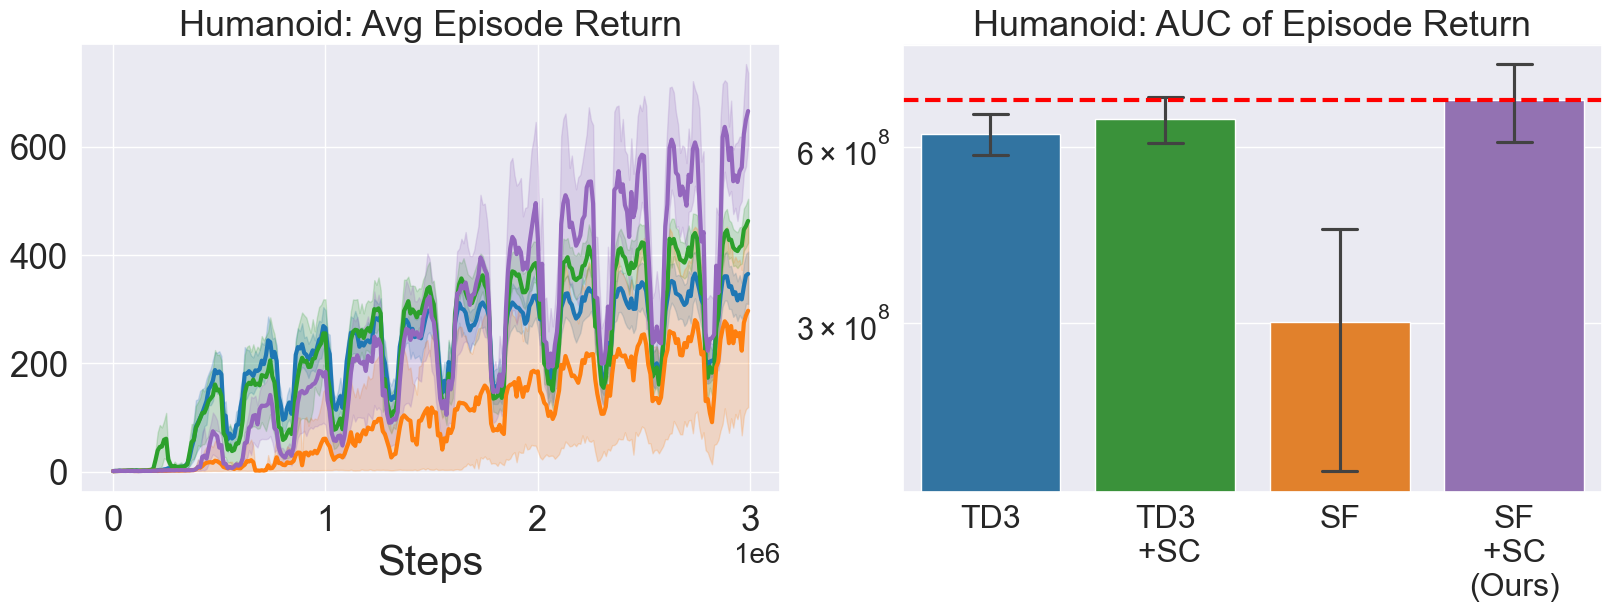

In [30]:
# plot is it better to consolidate parameters of Q-values or SFs?

from matplotlib.ticker import MaxNLocator, LogLocator

fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
# LEFT

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg"]],
    label=agents_new_names["ddpg"],
    color=color_code[agents_new_names["ddpg"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
     ax=axes[0],
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_beakers_params_continuous"]],
    label=agents_new_names["ddpg_beakers_params_continuous"],
    color=color_code[agents_new_names["ddpg_beakers_params_continuous"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple"]],
    label=agents_new_names["sf_simple"],
    color=color_code[agents_new_names["sf_simple"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params"]],
    label=agents_new_names["sf_simple_beakers_params"],
    color=color_code[agents_new_names["sf_simple_beakers_params"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

# Right
last_rows = runs_df.groupby(["agent_name", "agent_seed"], as_index=False).tail(1)



# Right
def compute_auc(group):
    return trapezoid(group["eval/episode_reward"], group["eval/step"])
auc_df = (
    runs_df.groupby(["agent_name", "agent_seed"], group_keys=False)
      .apply(compute_auc, include_groups=False)
      .reset_index(name="AUC")
)

agents_to_plot = ["TD3", "TD3 + SC", "SF", "SF + SC (Ours)",]
subset = auc_df[auc_df["agent_name"].isin(agents_to_plot)]
subset["agent_name_pretty"] = subset["agent_name"].str.replace(" + ", "\n +", regex=False)
subset["agent_name_pretty"] = subset["agent_name_pretty"].str.replace(
    "SF\n +SC (Ours)", "SF\n +SC \n(Ours)", regex=False
)
# agents_to_plot is defined earlier
agents_order = [name.replace(" + ", "\n +") for name in agents_to_plot]
agents_order[-1] = "SF\n +SC \n(Ours)"


# Ensure subset has the pretty labels and exact category order
# subset["agent_name_pretty"] = subset["agent_name"].str.replace(" + ", "\n +", regex=False)
# subset.loc[subset["agent_name_pretty"] == "SF\n +SC (Ours)", "agent_name_pretty"] = "SF\n + SC \n(Ours)"

subset["agent_name_pretty"] = pd.Categorical(subset["agent_name_pretty"],
                                             categories=agents_order,
                                             ordered=True)
print(subset["agent_name_pretty"].unique())

ax = sns.barplot(data=subset, x="agent_name_pretty", y="AUC", palette=color_code, errorbar="se", capsize=0.2, hue="agent_name_pretty")

mean_val = subset[subset["agent_name"] == agents_new_names["sf_simple_beakers_params"]]["AUC"].mean()
ax.axhline(mean_val, color="red", linestyle="--", linewidth=3)


axes[0].set_title("Humanoid: Avg Episode Return", fontsize=26)
axes[0].set_xlabel("Steps", fontsize=30)
axes[0].set_ylabel("", fontsize=30)
# axes[0].legend(loc="upper left", fontsize=18)
axes[0].legend().set_visible(False)
axes[0].tick_params(axis="x", labelsize=25)
axes[0].tick_params(axis="y", labelsize=25)
axes[0].xaxis.get_offset_text().set_fontsize(20)

axes[1].set_xlabel("", fontsize=14)
axes[1].set_ylabel("", fontsize=14)
axes[1].set_title("Humanoid: AUC of Episode Return", fontsize=26)
axes[1].tick_params(axis="x", labelsize=23)
axes[1].tick_params(axis="y", labelsize=22)
axes[1].set_yscale("log")
axes[1].yaxis.set_major_locator(MaxNLocator(nbins=3))
axes[1].yaxis.set_minor_locator(LogLocator(base=10.0, subs=[]))     # no minor ticks

filename = "consolidate_qvals_sf_analysis_" + domain + "_" + cfg.mode
fig.savefig(filename + ".pdf", bbox_inches="tight")
plt.show()


['PPO' 'SF' 'SF + EWC' 'SF + SC (Ours)' 'SF + SC + Attention (Ours)' 'TD3'
 'TD3 + CBP' 'TD3 + EWC' 'TD3 + P-last' 'TD3 + SC']


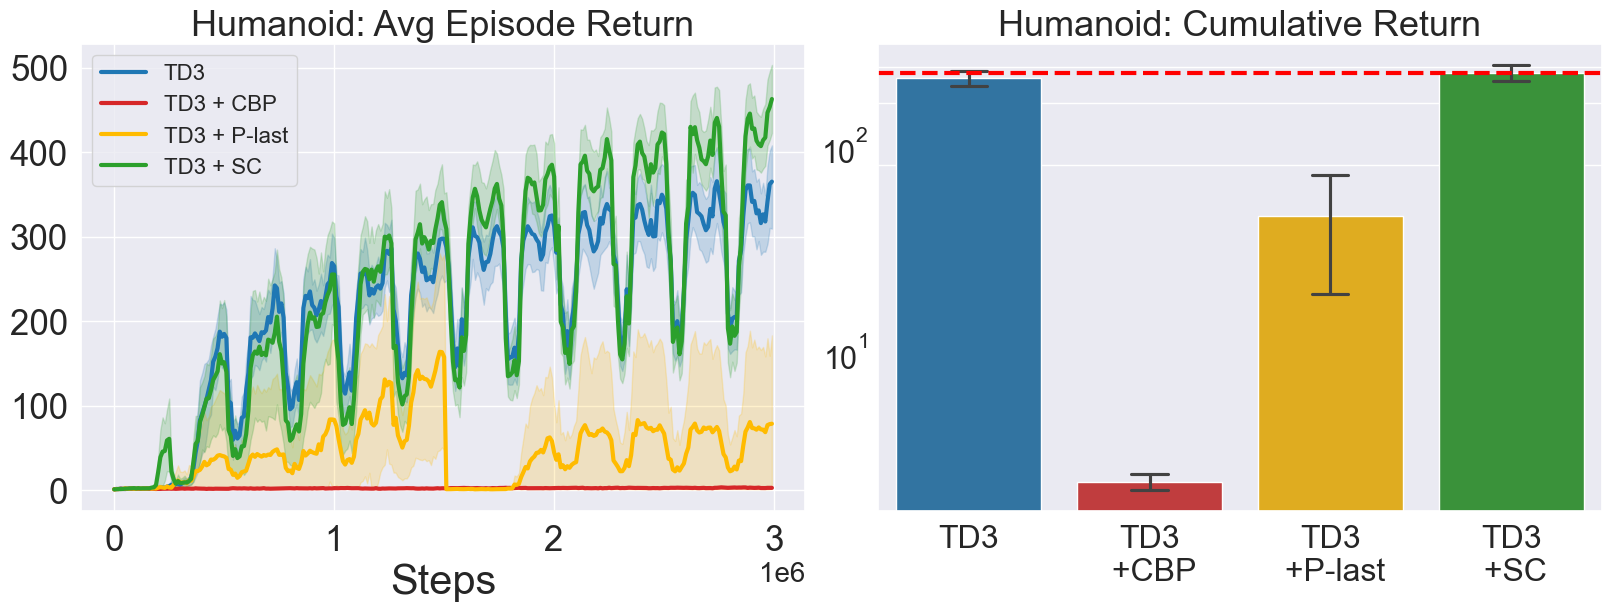

In [31]:
# Plot for Plasticity-Stability Analysis

from matplotlib.ticker import MaxNLocator, LogLocator

fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
# LEFT

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg"]],
    label=agents_new_names["ddpg"],
    color=color_code[agents_new_names["ddpg"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
     ax=axes[0],
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_continual_backprop"]],
    label=agents_new_names["ddpg_continual_backprop"],
    color=color_code[agents_new_names["ddpg_continual_backprop"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_plasticity_injection_last_layer"]],
    label=agents_new_names["ddpg_plasticity_injection_last_layer"],
    color=color_code[agents_new_names["ddpg_plasticity_injection_last_layer"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0]
)


sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_beakers_params_continuous"]],
    label=agents_new_names["ddpg_beakers_params_continuous"],
    color=color_code[agents_new_names["ddpg_beakers_params_continuous"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)


# Right
last_rows = runs_df.groupby(["agent_name", "agent_seed"], as_index=False).tail(1)
agents_to_plot = ["TD3", "TD3 + P-last", "TD3 + CBP", "TD3 + SC", ]
subset = last_rows[last_rows["agent_name"].isin(agents_to_plot)]
print(runs_df["agent_name"].unique())
sns.barplot(data=subset, x="agent_name_pretty", y="norm_cum_reward", palette=color_code, ax=axes[1], errorbar="se", capsize=0.2, hue="agent_name_pretty")

mean_val = subset[subset["agent_name"] == "TD3 + SC"]["norm_cum_reward"].mean()
axes[1].axhline(mean_val, color="red", linestyle="--", linewidth=3)

# fig.suptitle("Consolidating Q-values vs SFs under Mass Changes", fontsize=18)

axes[0].set_title("Humanoid: Avg Episode Return", fontsize=26)
axes[0].set_xlabel("Steps", fontsize=30)
axes[0].set_ylabel("", fontsize=30)
axes[0].legend(loc="upper left", fontsize=16, ncol=1)
axes[0].tick_params(axis="x", labelsize=25)
axes[0].tick_params(axis="y", labelsize=25)
axes[0].xaxis.get_offset_text().set_fontsize(20)

axes[1].set_xlabel("", fontsize=14)
axes[1].set_ylabel("", fontsize=14)
axes[1].set_title("Humanoid: Cumulative Return", fontsize=26)
axes[1].tick_params(axis="x", labelsize=23)
axes[1].tick_params(axis="y", labelsize=22, which="both")
axes[1].set_yscale("log")
axes[1].yaxis.set_major_locator(MaxNLocator(nbins=4))
axes[1].yaxis.set_minor_locator(LogLocator(base=10.0, subs=[]))     # no minor ticks

filename = "plasticity_stability_analysis_" + domain + "_" + cfg.mode
fig.savefig(filename + ".pdf", bbox_inches="tight")
plt.show()


/var/folders/60/3nwk45px1hj7s9fk4rz760qc0000gn/T/ipykernel_9254/1007441836.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["agent_name_pretty"] = subset["agent_name"].str.replace(" + ", "\n +", regex=False)


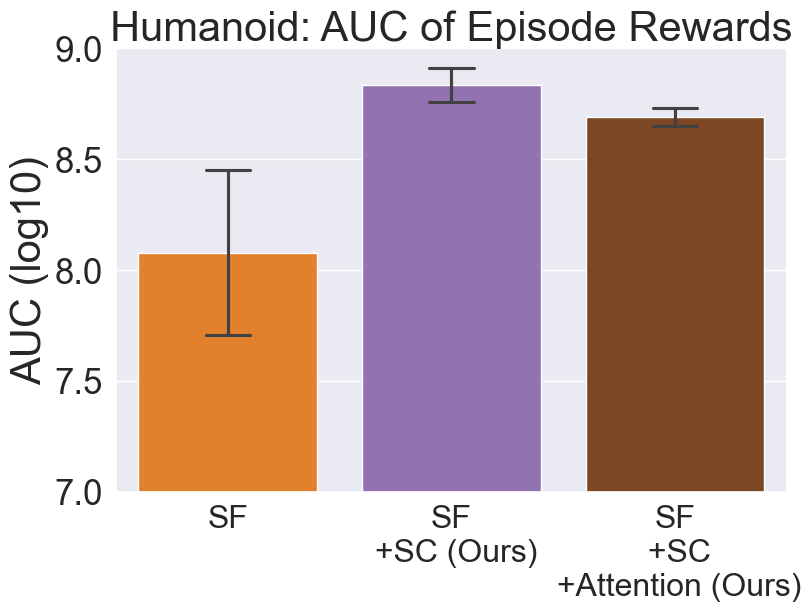

In [32]:
from scipy.integrate import trapezoid

colors = sns.color_palette("colorblind", 3)
plt.figure(figsize=(8,6), constrained_layout=True)

def compute_auc(group):
    return trapezoid(group["eval/episode_reward"], group["eval/step"])
auc_df = (
    runs_df.groupby(["agent_name", "agent_seed"], group_keys=False)
      .apply(compute_auc, include_groups=False)
      .reset_index(name="AUC")
)

# last_rows = runs_df.groupby(["agent_name", "agent_seed"], as_index=False).tail(1)
agents_to_plot = ["SF", "SF + SC (Ours)", "SF + SC + Attention (Ours)"]
# agents_to_plot = ["TD3", "TD3 + CBP", "TD3 + EWC", "TD3 + SC", "SF + SC (Ours)"]
subset = auc_df[auc_df["agent_name"].isin(agents_to_plot)]
subset["agent_name_pretty"] = subset["agent_name"].str.replace(" + ", "\n +", regex=False)
# subset.loc[subset["agent_name_pretty"] == "SF\n +SC (Ours)", "agent_name_pretty"] = "SF\n +SC \n(Ours)"
# subset.loc[subset["agent_name_pretty"] == "SF\n +SC (Ours)", "agent_name_pretty"] = "SF\n +SC\n +Attention (Ours)"
# ax = sns.barplot(data=subset, x="agent_name_pretty", y="AUC", palette=color_code, errorbar="se", capsize=0.2, hue="agent_name_pretty")


# pick the last row per agent (largest step)
# last_rows = runs_df.groupby(["agent_name", "agent_seed"], as_index=False).tail(1)
#
# agents_to_plot = ["TD3", "SF", "TD3 + SC", "SF + SC (Ours)", "SF + SC + Attention (Ours)"]
# subset = last_rows[last_rows["agent_name"].isin(agents_to_plot)]
#
# print(color_code)
# print(subset["agent_name_pretty"])
#
# subset["agent_name_pretty"] = subset["agent_name_pretty"].replace(
#     "SF\n +SC (Ours)", "SF\n +SC"
# )
#
# #
# subset["agent_name_pretty"] = subset["agent_name_pretty"].replace(
#     "SF\n +SC\n +Attention (Ours)", "SF\n +SC\n +Attention"
# )

# {'TD3': '#1f77b4', 'SF': '#ff7f0e', 'TD3 + SC': '#2ca02c', 'SF + SC (Ours)': '#9467bd', 'SF + SC': '#9467bd', 'TD3 + Plasticity (last layer)': '#2ca02c', 'TD3 + Plasticity (last few layers)': '#d62728', 'SF + SC + Attention': '#6F4E37', 'SF + SC + Attention (Ours)': '#6F4E37', 'TD3\n +SC': '#2ca02c', 'SF\n +SC (Ours)': '#9467bd', 'SF\n +SC\n +Attention (Ours)': '#6F4E37', 'SF + EWC': '#e377c2', 'TD3 + EWC': '#bcbd22', 'SF\n +EWC': '#e377c2', 'TD3\n +EWC': '#bcbd22'}
eps = 1e-12  # in case any values are 0
subset = subset.copy()
subset["AUC_log10"] = np.log10(subset["AUC"].clip(lower=eps))
ax = sns.barplot(data=subset, x="agent_name_pretty", y="AUC_log10", palette=color_code,  errorbar="se", capsize=0.2, hue="agent_name_pretty")

#
# mean_val = subset[subset["agent_name"] == agents_new_names["sf_simple_beakers_params"]]["AUC"].mean()
# ax.axhline(mean_val, color="red", linestyle="--", linewidth=3)

# agents_to_plot = ["TD3", "SF", "TD3 + SC", "SF + SC",]
# subset = auc_df[auc_df["agent_name"].isin(agents_to_plot)]


# ax = sns.barplot(
#     data=auc_df,
#     x="agent_num_beakers",
#     y="AUC",
#     errorbar="sd",   # std deviation across seeds
#     capsize=0.2,
#     hue="agent_num_beakers",
#     legend=False,
#     palette=colors,
#
# )colors
plt.title("Humanoid: AUC of Episode Rewards", fontsize=30)
plt.ylabel("AUC (log10)", fontsize=30)
plt.xlabel("")
plt.xticks(fontsize=23)
plt.yticks(fontsize=25)
ax.set_ylim(7, 9)
# plt.yscale("log")
# ax.yaxis.get_offset_text().set_visible(False)
ax.yaxis.set_major_locator(MaxNLocator(nbins=4))
# ax.yaxis.set_minor_locator(LogLocator(base=10.0,  numticks=3))     # no minor ticks
# ax.yaxis.get_offset_text().set_visible(False)
filename = "attention_AUC_analysis_" + domain + "_" + cfg.mode
plt.savefig(filename + ".pdf")
plt.show()

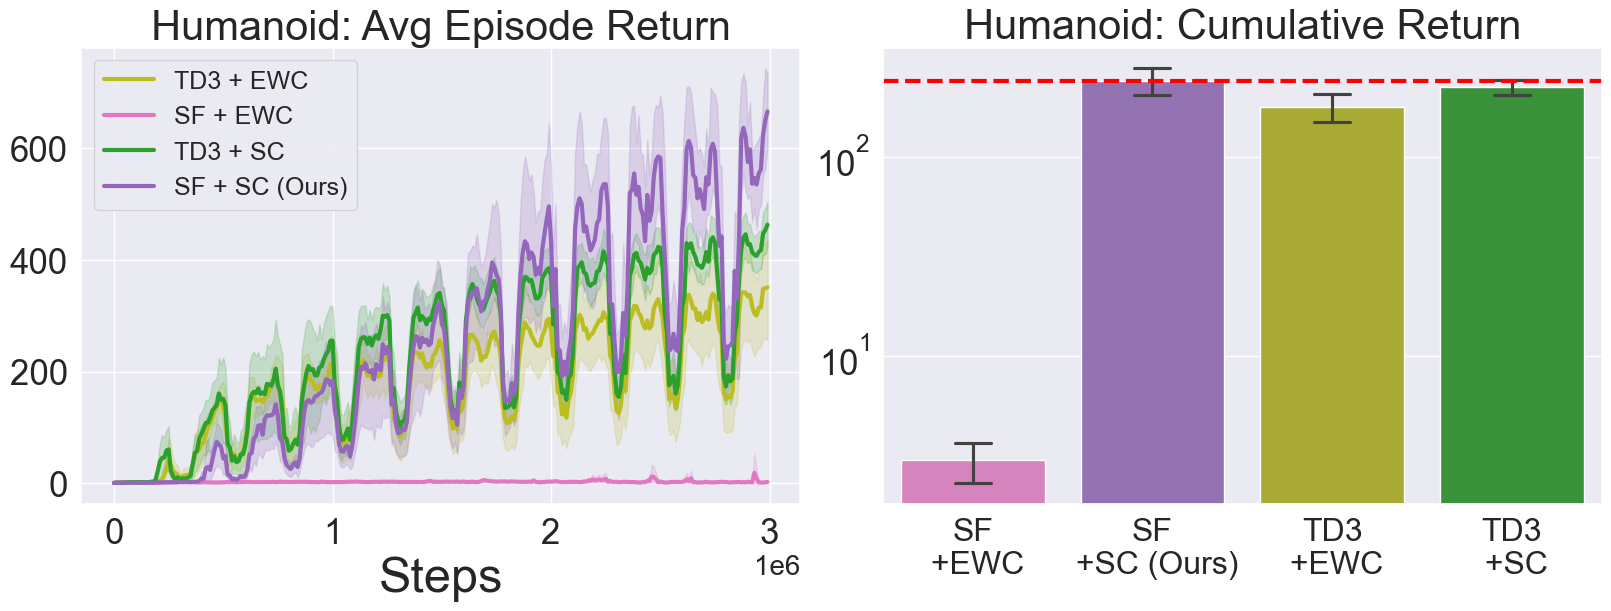

In [33]:
# Comparing with EWC
fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

# LEFT
# sns.lineplot(
#     x="eval/step",
#     y="eval/episode_reward",
#     data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg"]],
#     label=agents_new_names["ddpg"],
#     color=color_code[agents_new_names["ddpg"]],
#     linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
#     ax=axes[0],
#     linestyle="--",
# )
#
# sns.lineplot(
#     x="eval/step",
#     y="eval/episode_reward",
#     data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple"]],
#     label=agents_new_names["sf_simple"],
#     color=color_code[agents_new_names["sf_simple"]],
#     linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
#     ax=axes[0],
#     linestyle="--",
# )

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_online_ewc"]],
    label=agents_new_names["ddpg_online_ewc"],
    color=color_code[agents_new_names["ddpg_online_ewc"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_online_ewc"]],
    label=agents_new_names["sf_online_ewc"],
    color=color_code[agents_new_names["sf_online_ewc"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_beakers_params_continuous"]],
    label=agents_new_names["ddpg_beakers_params_continuous"],
    color=color_code[agents_new_names["ddpg_beakers_params_continuous"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params"]],
    label=agents_new_names["sf_simple_beakers_params"],
    color=color_code[agents_new_names["sf_simple_beakers_params"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

# sns.lineplot(
#     x="eval/step",
#     y="eval/episode_reward",
#     data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
#     label=agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"],
#     color=color_code[agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
#     linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
#     ax=axes[0],
# )




# RIGHT

# pick the last row per agent (largest step)
last_rows = runs_df.groupby(["agent_name", "agent_seed"], as_index=False).tail(1)

agents_to_plot = ["TD3 + SC", "SF + SC (Ours)", "TD3 + EWC", "SF + EWC"]
subset = last_rows[last_rows["agent_name"].isin(agents_to_plot)]
sns.barplot(data=subset, x="agent_name_pretty", y="norm_cum_reward", palette=color_code, ax=axes[1], errorbar="se", capsize=0.2, hue="agent_name_pretty")

mean_val = subset[subset["agent_name"] == "SF + SC (Ours)"]["norm_cum_reward"].mean()
axes[1].axhline(mean_val, color="red", linestyle="--", linewidth=3)

# for bar, (agent, score) in zip(axes[1].patches, subset[["agent_name","norm_cum_reward"]].values):
#     print(agent)
    # if "SC" in agent:  # only annotate the SC bars
    #     if "TD3" in agent:
    #         base = baselines["TD3"]
    #     elif "SF" in agent:
    #         base = baselines["SF"]
    #
    #     pct_gain = 100 * (score - base) / base
    #     axes[1].text(
    #         bar.get_x() + bar.get_width()/2,
    #         bar.get_height(),
    #         f"+{pct_gain:.1f}%",
    #         ha="center", va="bottom", fontsize=9, fontweight="bold"
    #     )

# fig.suptitle("Multi-timescale Synaptic Consolidation vs Elastic Weight Consolidation (EWC)", fontsize=18)

# axes[0].set_xlabel("", fontsize=14)
# axes[0].set_ylabel("Total Cumulative Return", fontsize=14)
# # axes[0].set_title("Total Cumulative Returns (Evaluation)", fontsize=16)
# axes[0].tick_params(axis="x", labelsize=15)
# axes[0].tick_params(axis="y", labelsize=18)
# axes[0].set_yscale("log")
#
# # axes[1].set_title("Episode Returns (Evaluation)", fontsize=16)
# axes[1].set_xlabel("Steps", fontsize=15)
# axes[1].set_ylabel("Episode Returns", fontsize=15)
# axes[1].legend(loc="lower left", fontsize=12)
# axes[1].tick_params(axis="x", labelsize=15)
# axes[1].tick_params(axis="y", labelsize=18)

axes[0].set_title("Humanoid: Avg Episode Return", fontsize=30)
axes[0].set_xlabel("Steps", fontsize=35)
axes[0].set_ylabel("", fontsize=30)
axes[0].legend(loc="upper left", fontsize=18)
axes[0].tick_params(axis="x", labelsize=25)
axes[0].tick_params(axis="y", labelsize=25)
axes[0].xaxis.get_offset_text().set_fontsize(20)

axes[1].set_xlabel("", fontsize=14)
axes[1].set_ylabel("", fontsize=14)
axes[1].set_title("Humanoid: Cumulative Return", fontsize=30)
axes[1].tick_params(axis="x", labelsize=23)
axes[1].tick_params(axis="y", labelsize=25, which="both")
axes[1].set_yscale("log")
# axes[1].yaxis.set_major_locator(MaxNLocator(nbins=3))
# axes[1].yaxis.set_minor_locator(LogLocator(base=10.0, subs=[]))     # no minor ticks

filename = "ewc_analysis_" + domain + "_" + cfg.mode
plt.savefig(filename + ".pdf")
plt.show()


/var/folders/60/3nwk45px1hj7s9fk4rz760qc0000gn/T/ipykernel_9254/1166587428.py:95: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["agent_name_pretty"] = subset["agent_name"].str.replace(" + ", "\n +", regex=False)


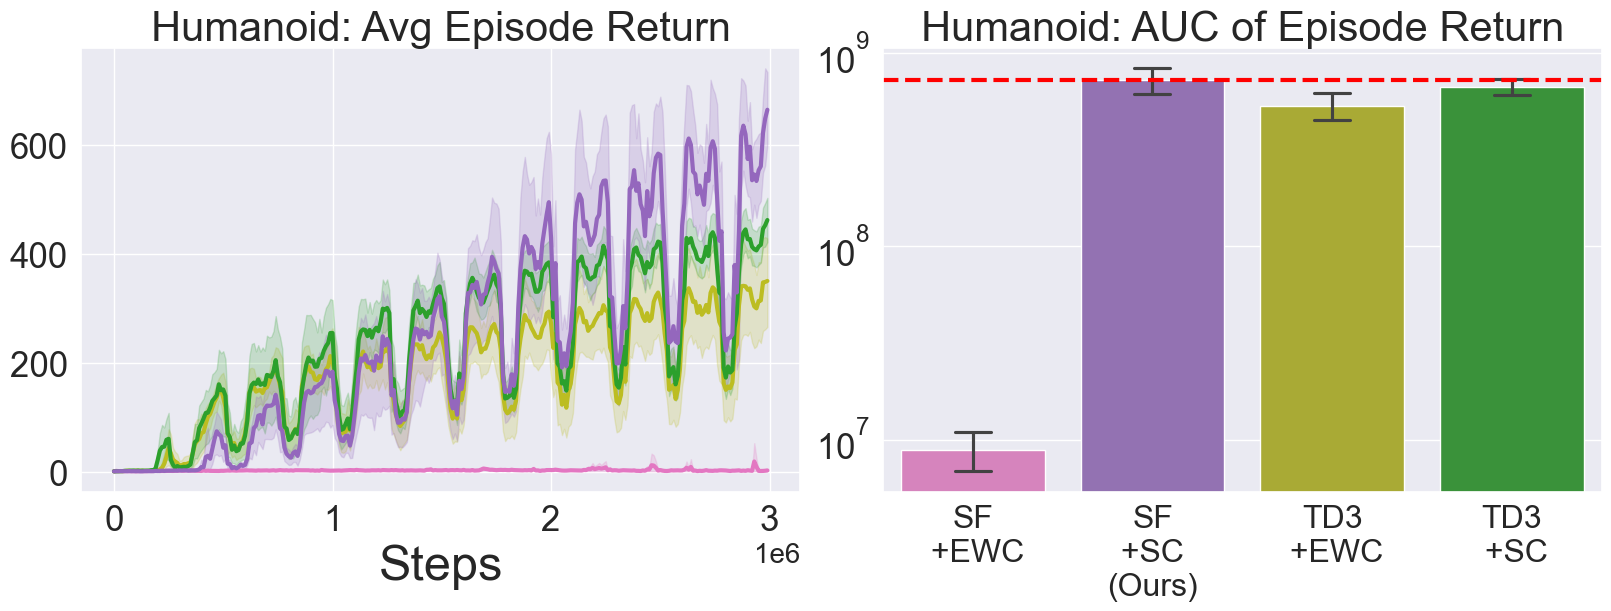

In [34]:
# Comparing with EWC
fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

# LEFT
# sns.lineplot(
#     x="eval/step",
#     y="eval/episode_reward",
#     data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg"]],
#     label=agents_new_names["ddpg"],
#     color=color_code[agents_new_names["ddpg"]],
#     linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
#     ax=axes[0],
#     linestyle="--",
# )
#
# sns.lineplot(
#     x="eval/step",
#     y="eval/episode_reward",
#     data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple"]],
#     label=agents_new_names["sf_simple"],
#     color=color_code[agents_new_names["sf_simple"]],
#     linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
#     ax=axes[0],
#     linestyle="--",
# )

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_online_ewc"]],
    label=agents_new_names["ddpg_online_ewc"],
    color=color_code[agents_new_names["ddpg_online_ewc"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_online_ewc"]],
    label=agents_new_names["sf_online_ewc"],
    color=color_code[agents_new_names["sf_online_ewc"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_beakers_params_continuous"]],
    label=agents_new_names["ddpg_beakers_params_continuous"],
    color=color_code[agents_new_names["ddpg_beakers_params_continuous"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params"]],
    label=agents_new_names["sf_simple_beakers_params"],
    color=color_code[agents_new_names["sf_simple_beakers_params"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

# sns.lineplot(
#     x="eval/step",
#     y="eval/episode_reward",
#     data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
#     label=agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"],
#     color=color_code[agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
#     linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
#     ax=axes[0],
# )




# RIGHT

# pick the last row per agent (largest step)
def compute_auc(group):
    return trapezoid(group["eval/episode_reward"], group["eval/step"])
auc_df = (
    runs_df.groupby(["agent_name", "agent_seed"], group_keys=False)
      .apply(compute_auc, include_groups=False)
      .reset_index(name="AUC")
)

# last_rows = runs_df.groupby(["agent_name", "agent_seed"], as_index=False).tail(1)
agents_to_plot = ["TD3 + EWC", "TD3 + SC", "SF + EWC", "SF + SC (Ours)"]
# agents_to_plot = ["TD3", "TD3 + CBP", "TD3 + EWC", "TD3 + SC", "SF + SC (Ours)"]
subset = auc_df[auc_df["agent_name"].isin(agents_to_plot)]
subset["agent_name_pretty"] = subset["agent_name"].str.replace(" + ", "\n +", regex=False)
subset.loc[subset["agent_name_pretty"] == "SF\n +SC (Ours)", "agent_name_pretty"] = "SF\n +SC \n(Ours)"
ax = sns.barplot(data=subset, x="agent_name_pretty", y="AUC", palette=color_code, errorbar="se", capsize=0.2, hue="agent_name_pretty")

mean_val = subset[subset["agent_name"] == "SF + SC (Ours)"]["AUC"].mean()
axes[1].axhline(mean_val, color="red", linestyle="--", linewidth=3)

# for bar, (agent, score) in zip(axes[1].patches, subset[["agent_name","norm_cum_reward"]].values):
#     print(agent)
    # if "SC" in agent:  # only annotate the SC bars
    #     if "TD3" in agent:
    #         base = baselines["TD3"]
    #     elif "SF" in agent:
    #         base = baselines["SF"]
    #
    #     pct_gain = 100 * (score - base) / base
    #     axes[1].text(
    #         bar.get_x() + bar.get_width()/2,
    #         bar.get_height(),
    #         f"+{pct_gain:.1f}%",
    #         ha="center", va="bottom", fontsize=9, fontweight="bold"
    #     )

# fig.suptitle("Multi-timescale Synaptic Consolidation vs Elastic Weight Consolidation (EWC)", fontsize=18)

# axes[0].set_xlabel("", fontsize=14)
# axes[0].set_ylabel("Total Cumulative Return", fontsize=14)
# # axes[0].set_title("Total Cumulative Returns (Evaluation)", fontsize=16)
# axes[0].tick_params(axis="x", labelsize=15)
# axes[0].tick_params(axis="y", labelsize=18)
# axes[0].set_yscale("log")
#
# # axes[1].set_title("Episode Returns (Evaluation)", fontsize=16)
# axes[1].set_xlabel("Steps", fontsize=15)
# axes[1].set_ylabel("Episode Returns", fontsize=15)
# axes[1].legend(loc="lower left", fontsize=12)
# axes[1].tick_params(axis="x", labelsize=15)
# axes[1].tick_params(axis="y", labelsize=18)

axes[0].set_title("Humanoid: Avg Episode Return", fontsize=30)
axes[0].set_xlabel("Steps", fontsize=35)
axes[0].set_ylabel("", fontsize=30)
# axes[0].legend(loc="upper left", fontsize=18)
axes[0].legend().set_visible(False)
axes[0].tick_params(axis="x", labelsize=25)
axes[0].tick_params(axis="y", labelsize=25)
axes[0].xaxis.get_offset_text().set_fontsize(20)

axes[1].set_xlabel("", fontsize=14)
axes[1].set_ylabel("", fontsize=14)
axes[1].set_title("Humanoid: AUC of Episode Return", fontsize=30)
axes[1].tick_params(axis="x", labelsize=23)
axes[1].tick_params(axis="y", labelsize=25, which="both")
axes[1].set_yscale("log")
# axes[1].yaxis.set_major_locator(MaxNLocator(nbins=3))
# axes[1].yaxis.set_minor_locator(LogLocator(base=10.0, subs=[]))     # no minor ticks

filename = "consolidate_qvals_vs_sf_analysis_" + domain + "_" + cfg.mode
plt.savefig(filename + ".pdf")
plt.show()


/var/folders/60/3nwk45px1hj7s9fk4rz760qc0000gn/T/ipykernel_9254/1808266784.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["agent_name_pretty"] = subset["agent_name"].str.replace(" + ", "\n +", regex=False)


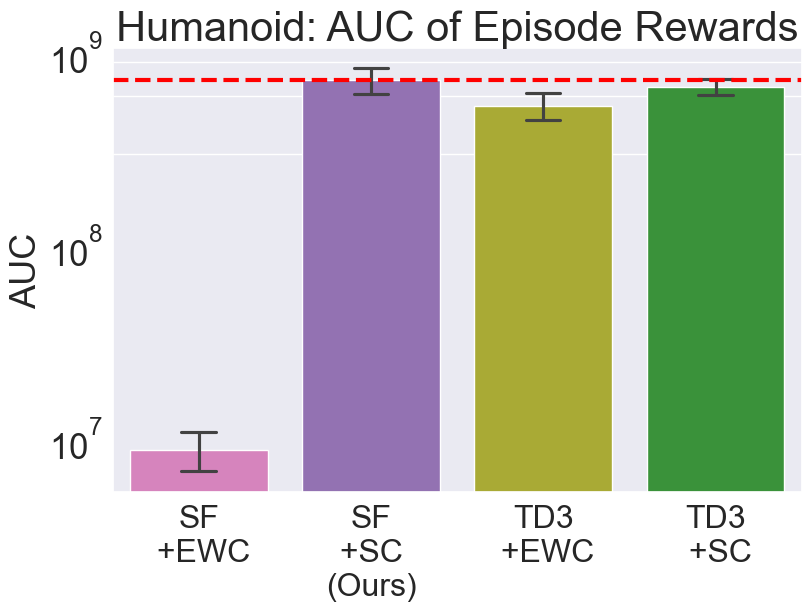

In [35]:


colors = sns.color_palette("colorblind", 3)
plt.figure(figsize=(8,6), constrained_layout=True)

def compute_auc(group):
    return trapezoid(group["eval/episode_reward"], group["eval/step"])
auc_df = (
    runs_df.groupby(["agent_name", "agent_seed"], group_keys=False)
      .apply(compute_auc, include_groups=False)
      .reset_index(name="AUC")
)

# last_rows = runs_df.groupby(["agent_name", "agent_seed"], as_index=False).tail(1)
agents_to_plot = ["SF", "SF + SC (Ours)", "SF + SC + Attention (Ours)"]
# agents_to_plot = ["TD3", "TD3 + CBP", "TD3 + EWC", "TD3 + SC", "SF + SC (Ours)"]
auc_df = (
    runs_df.groupby(["agent_name", "agent_seed"], group_keys=False)
      .apply(compute_auc, include_groups=False)
      .reset_index(name="AUC")
)

# last_rows = runs_df.groupby(["agent_name", "agent_seed"], as_index=False).tail(1)
agents_to_plot = ["TD3 + EWC", "TD3 + SC", "SF + EWC", "SF + SC (Ours)"]
# agents_to_plot = ["TD3", "TD3 + CBP", "TD3 + EWC", "TD3 + SC", "SF + SC (Ours)"]
subset = auc_df[auc_df["agent_name"].isin(agents_to_plot)]
subset["agent_name_pretty"] = subset["agent_name"].str.replace(" + ", "\n +", regex=False)
subset.loc[subset["agent_name_pretty"] == "SF\n +SC (Ours)", "agent_name_pretty"] = "SF\n +SC \n(Ours)"
ax = sns.barplot(data=subset, x="agent_name_pretty", y="AUC", palette=color_code, errorbar="se", capsize=0.2, hue="agent_name_pretty")

mean_val = subset[subset["agent_name"] == "SF + SC (Ours)"]["AUC"].mean()
ax.axhline(mean_val, color="red", linestyle="--", linewidth=3)

#
# mean_val = subset[subset["agent_name"] == agents_new_names["sf_simple_beakers_params"]]["AUC"].mean()
# ax.axhline(mean_val, color="red", linestyle="--", linewidth=3)

# agents_to_plot = ["TD3", "SF", "TD3 + SC", "SF + SC",]
# subset = auc_df[auc_df["agent_name"].isin(agents_to_plot)]


# ax = sns.barplot(
#     data=auc_df,
#     x="agent_num_beakers",
#     y="AUC",
#     errorbar="sd",   # std deviation across seeds
#     capsize=0.2,
#     hue="agent_num_beakers",
#     legend=False,
#     palette=colors,
#
# )colors
plt.title("Humanoid: AUC of Episode Rewards", fontsize=30)
plt.ylabel("AUC", fontsize=26)
plt.xlabel("")
plt.xticks(fontsize=23)
plt.yticks(fontsize=25)
# ax.set_ylim(7, 9)
plt.yscale("log")
# ax.yaxis.get_offset_text().set_visible(False)
ax.yaxis.set_major_locator(MaxNLocator(nbins=4))
ax.yaxis.set_minor_locator(LogLocator(base=10.0,  numticks=3))     # no minor ticks
ax.tick_params(axis="y", labelsize=25, which="both")
# ax.yaxis.get_offset_text().set_visible(False)
filename = "qvals_sf_ewc_sc_AUC_analysis_" + domain + "_" + cfg.mode
plt.savefig(filename + ".pdf")
plt.show()

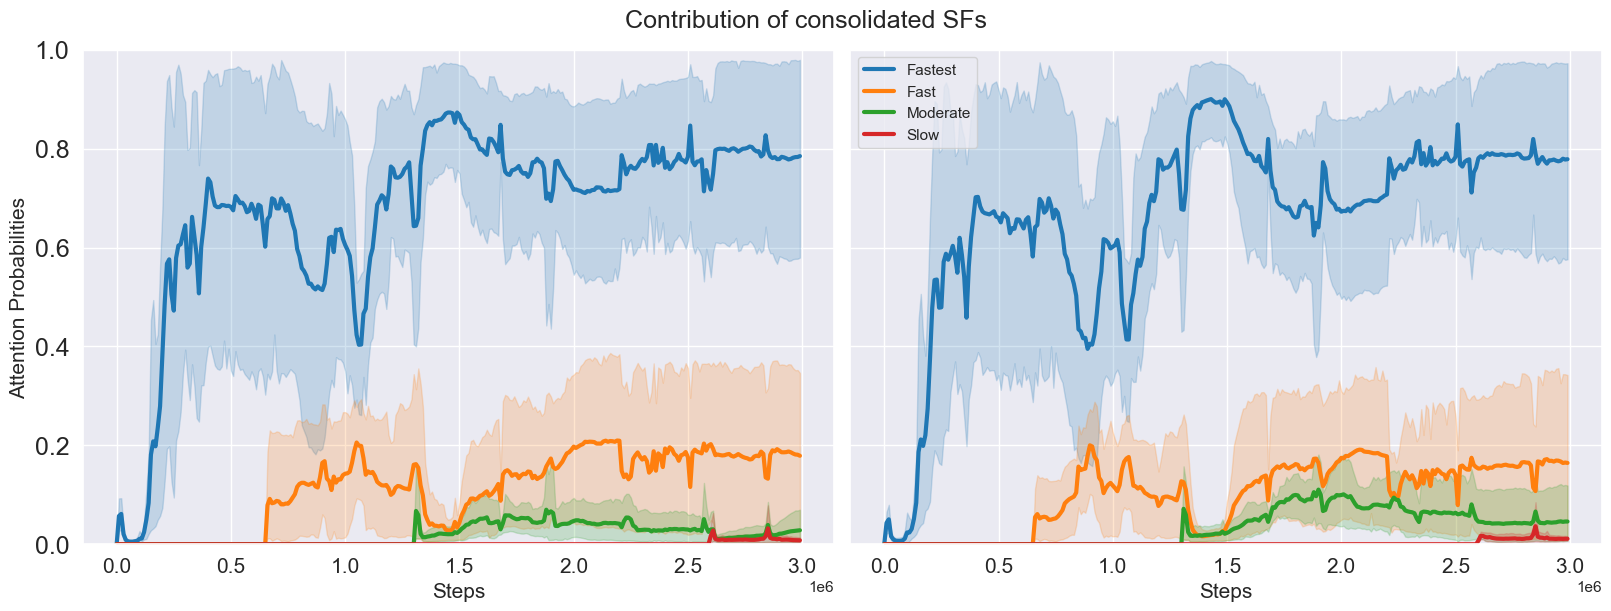

In [36]:
# Understanding the attention mechanism
fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True, sharey=True)

colors_attention = ["#1F77B4", "#FF7F0E", "#2CA02C", "#D62728", "#9467BD", "#8C564B", "#17BECF"]

# LEFT

sns.lineplot(
    x="eval/step",
    y="train/attention_distribution1_u_0_mean",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
    label="Fastest",
    color=colors_attention[0],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
    legend=False,
)

sns.lineplot(
    x="eval/step",
    y="train/attention_distribution1_u_1_mean",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
    label="Fast",
    color=colors_attention[1],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
    legend=False,
)

sns.lineplot(
    x="eval/step",
    y="train/attention_distribution1_u_2_mean",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
    label="Moderate",
    color=colors_attention[2],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
    legend=False,
)

sns.lineplot(
    x="eval/step",
    y="train/attention_distribution1_u_3_mean",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
    label="Slow",
    color=colors_attention[3],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
    legend=False,
)

# sns.lineplot(
#     x="eval/step",
#     y="train/attention_distribution1_u_4_mean",
#     data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
#     label="Slower",
#     color=colors_attention[4],
#     linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
#     ax=axes[0],
#     legend=False,
# )

# sns.lineplot(
#     x="eval/step",
#     y="train/attention_distribution1_u_5_mean",
#     data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
#     label="Slowest",
#     color=colors_attention[5],
#     linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
#     ax=axes[0],
#     legend=False,
# )
#
# sns.lineplot(
#     x="eval/step",
#     y="train/attention_distribution1_u_6_mean",
#     data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
#     label="Persistent",
#     color=colors_attention[6],
#     linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
#     ax=axes[0],
#     legend=False,
# )



# RIGHT
sns.lineplot(
    x="eval/step",
    y="train/attention_distribution2_u_0_mean",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
    label="Fastest",
    color=colors_attention[0],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[1],
)

sns.lineplot(
    x="eval/step",
    y="train/attention_distribution2_u_1_mean",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
    label="Fast",
    color=colors_attention[1],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[1],
)

sns.lineplot(
    x="eval/step",
    y="train/attention_distribution2_u_2_mean",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
    label="Moderate",
    color=colors_attention[2],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[1],
)

sns.lineplot(
    x="eval/step",
    y="train/attention_distribution2_u_3_mean",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
    label="Slow",
    color=colors_attention[3],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[1],
)

# sns.lineplot(
#     x="eval/step",
#     y="train/attention_distribution2_u_4_mean",
#     data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
#     label="Slower",
#     color=colors_attention[4],
#     linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
#     ax=axes[1],
# )

# sns.lineplot(
#     x="eval/step",
#     y="train/attention_distribution2_u_5_mean",
#     data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
#     label="Slowest",
#     color=colors_attention[5],
#     linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
#     ax=axes[1],
# )
#
# sns.lineplot(
#     x="eval/step",
#     y="train/attention_distribution2_u_6_mean",
#     data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
#     label="Persistent",
#     color=colors_attention[6],
#     linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
#     ax=axes[1],
# )

fig.suptitle("Contribution of consolidated SFs", fontsize=18)

axes[0].set_xlabel("Steps", fontsize=15)
axes[0].set_ylabel("Attention Probabilities", fontsize=15)
# axes[0].set_title("Total Cumulative Returns (Evaluation)", fontsize=16)
axes[0].tick_params(axis="x", labelsize=15)
axes[0].tick_params(axis="y", labelsize=18)
# Set y-axis limits for each subplot
axes[0].set_ylim(0, 1.0)  # Set y-axis limits for the first subplot


axes[1].set_xlabel("Steps", fontsize=15)
axes[1].tick_params(axis="x", labelsize=15)

# # axes[1].set_title("Episode Returns (Evaluation)", fontsize=16)
# axes[1].set_xlabel("Steps", fontsize=15)
# axes[1].set_ylabel("Episode Returns", fontsize=15)
# axes[1].legend(loc="upper right", fontsize=12)
# axes[1].tick_params(axis="x", labelsize=15)
# axes[1].tick_params(axis="y", labelsize=18)
# axes[1].set_ylim(0, 1.0)  # Set y-axis limits for the second subplot

filename = "sf_attention_dist_both_sets_" + domain + "_" + cfg.mode
plt.savefig(filename + ".pdf")
plt.show()


{'TD3': '#1f77b4', 'SF': '#ff7f0e', 'TD3 + SC': '#2ca02c', 'SF + SC (Ours)': '#9467bd', 'SF + SC': '#9467bd', 'TD3 + P-last': '#ffbb00', 'TD3 + Plasticity (last few layers)': '#d62728', 'SF + SC + Attention': '#8B4513', 'SF + SC + Attention (Ours)': '#8B4513', 'TD3\n +SC': '#2ca02c', 'SF\n +SC (Ours)': '#9467bd', 'SF\n +SC \n(Ours)': '#9467bd', 'SF\n +SC': '#9467bd', 'SF\n +SC\n +Attention (Ours)': '#8B4513', 'SF\n +SC\n +Attention': '#8B4513', 'SF + EWC': '#e377c2', 'TD3 + EWC': '#bcbd22', 'SF\n +EWC': '#e377c2', 'TD3\n +EWC': '#bcbd22', 'TD3 + CBP': '#d62728', 'TD3\n +CBP': '#d62728', 'TD3\n +P-last': '#ffbb00', 'PPO': '#17becf'}
                       agent_name  agent_seed  eval/step eval/episode_reward  \
14100                         PPO          97        NaN                 NaN   
14101                         PPO         194        NaN                 NaN   
14102                         PPO         291        NaN                 NaN   
14103                         PPO       

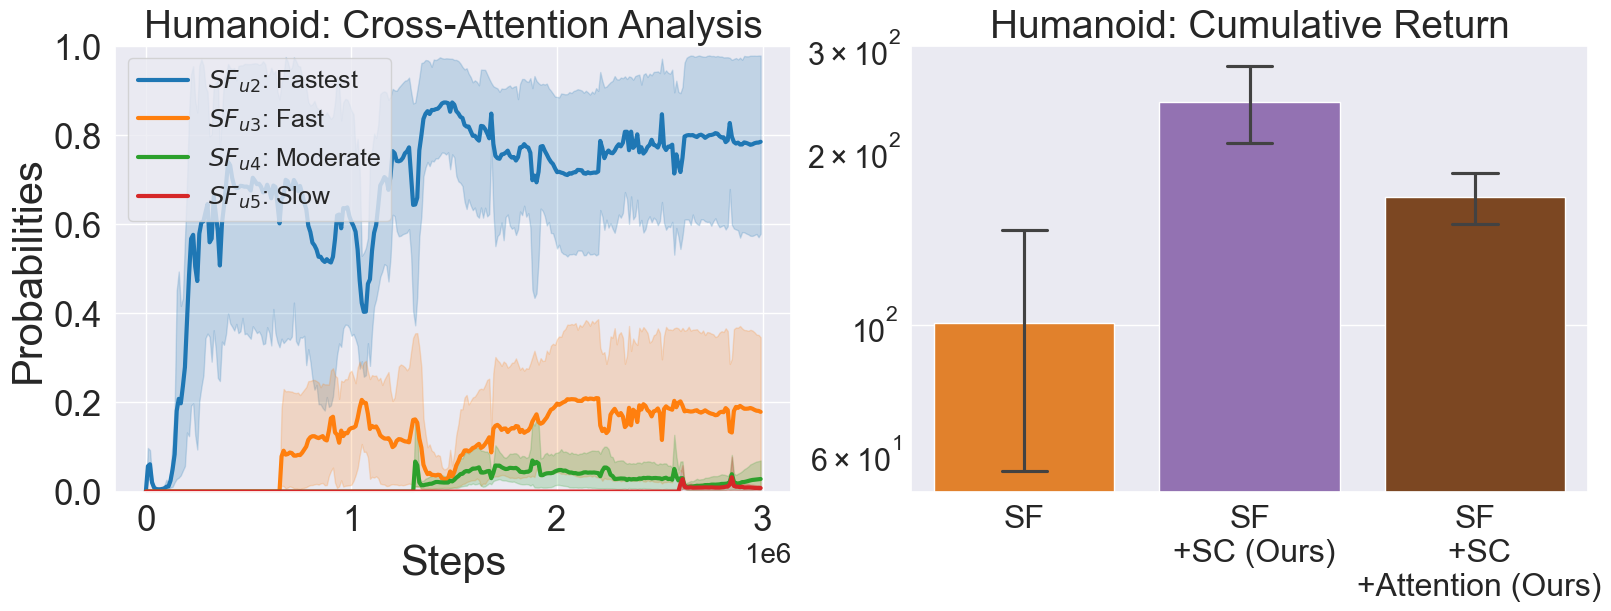

In [37]:
# Understanding the attention mechanism
fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

colors_attention = ["#1F77B4", "#FF7F0E", "#2CA02C", "#D62728", "#9467BD", "#8C564B", "#17BECF"]

# LEFT

sns.lineplot(
    x="eval/step",
    y="train/attention_distribution1_u_0_mean",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
    label=r"$SF_{u2}$: Fastest",
    color=colors_attention[0],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/step",
    y="train/attention_distribution1_u_1_mean",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
    label=r"$SF_{u3}$: Fast",
    color=colors_attention[1],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/step",
    y="train/attention_distribution1_u_2_mean",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
    label=r"$SF_{u4}$: Moderate",
    color=colors_attention[2],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/step",
    y="train/attention_distribution1_u_3_mean",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
    label=r"$SF_{u5}$: Slow",
    color=colors_attention[3],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

# sns.lineplot(
#     x="eval/step",
#     y="train/attention_distribution1_u_4_mean",
#     data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
#     label="Slower",
#     color=colors_attention[4],
#     linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
#     ax=axes[0],
#     legend=False,
# )

# sns.lineplot(
#     x="eval/step",
#     y="train/attention_distribution1_u_5_mean",
#     data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
#     label="Slowest",
#     color=colors_attention[5],
#     linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
#     ax=axes[0],
#     legend=False,
# )
#
# sns.lineplot(
#     x="eval/step",
#     y="train/attention_distribution1_u_6_mean",
#     data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
#     label="Persistent",
#     color=colors_attention[6],
#     linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
#     ax=axes[0],
#     legend=False,
# )


# RIGHT
# pick the last row per agent (largest step)
last_rows = runs_df.groupby(["agent_name", "agent_seed"], as_index=False).tail(1)

print(color_code)
print(last_rows)

agents_to_plot = ["SF", "SF + SC (Ours)", "SF + SC + Attention (Ours)"]
subset = last_rows[last_rows["agent_name"].isin(agents_to_plot)]
sns.barplot(data=subset, x="agent_name_pretty", y="norm_cum_reward", palette=color_code, errorbar="se", capsize=0.2, hue="agent_name_pretty", ax=axes[1])
# fig.suptitle("Contribution of consolidated SFs", fontsize=18)

axes[0].set_xlabel("Steps", fontsize=30)
axes[0].set_ylabel("Probabilities", fontsize=30)
axes[0].set_title("Humanoid: Cross-Attention Analysis", fontsize=28)
axes[0].tick_params(axis="x", labelsize=25, which="both")
axes[0].tick_params(axis="y", labelsize=25)
# Set y-axis limits for each subplot
axes[0].set_ylim(0, 1.0)  # Set y-axis limits for the first subplot
axes[0].legend(fontsize=18, loc="upper left", ncol=1, frameon=True)
axes[0].xaxis.get_offset_text().set_fontsize(20)

axes[1].set_title("Humanoid: Cumulative Return", fontsize=28)
axes[1].set_xlabel("")
axes[1].set_ylabel("")
axes[1].tick_params(axis="x", labelsize=23)
axes[1].tick_params(axis="y", labelsize=22, which="both")
axes[1].set_yscale("log")

# plt.subplots_adjust(wspace=0.8)   # increase space between columns

filename = "sf_attention_dist_and_cumulative_return" + domain + "_" + cfg.mode
plt.savefig(filename + ".pdf")
plt.show()


In [38]:
def compute_auc(group):
    return trapezoid(group["eval/episode_reward"], group["eval/step"])
auc_df = (
    runs_df.groupby(["agent_name", "agent_seed"], group_keys=False)
      .apply(compute_auc, include_groups=False)
      .reset_index(name="AUC")
)

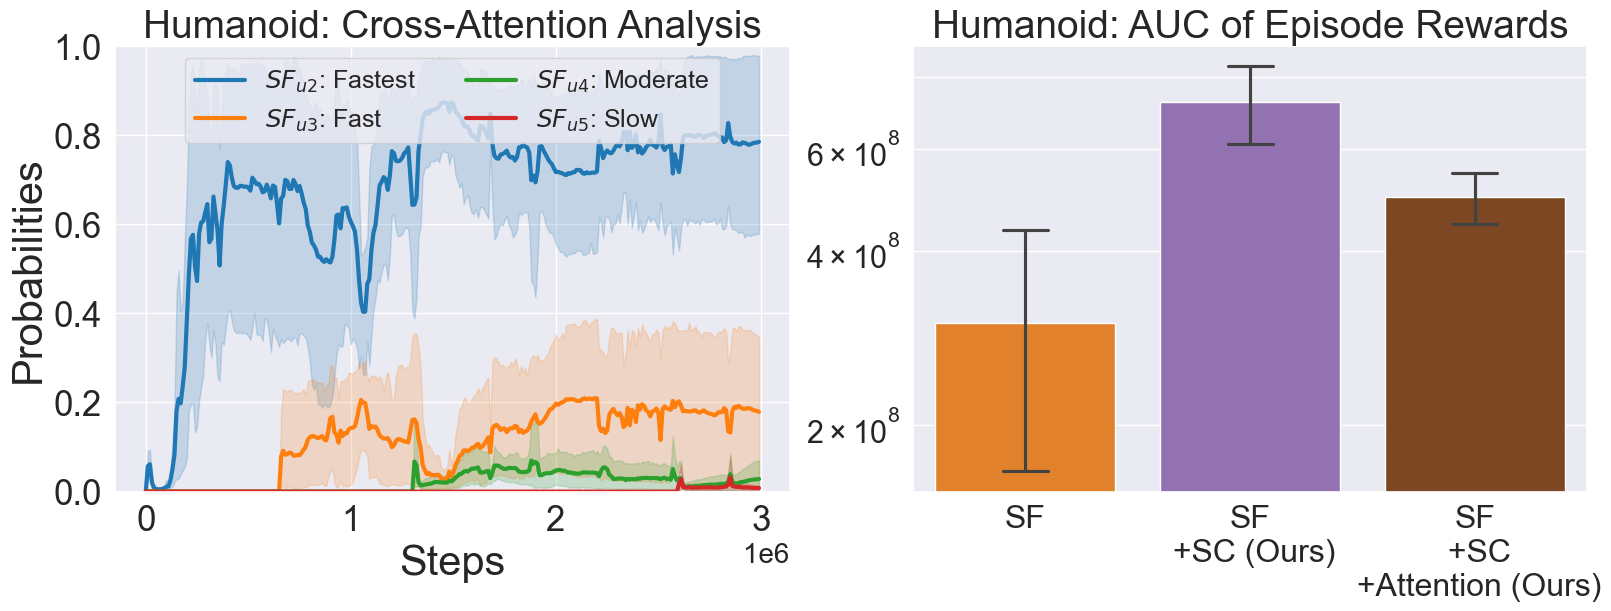

In [39]:
# Understanding the attention mechanism
fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

colors_attention = ["#1F77B4", "#FF7F0E", "#2CA02C", "#D62728", "#9467BD", "#8C564B", "#17BECF"]

# LEFT
sns.lineplot(
    x="eval/step",
    y="train/attention_distribution1_u_0_mean",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
    label=r"$SF_{u2}$: Fastest",
    color=colors_attention[0],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/step",
    y="train/attention_distribution1_u_1_mean",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
    label=r"$SF_{u3}$: Fast",
    color=colors_attention[1],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/step",
    y="train/attention_distribution1_u_2_mean",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
    label=r"$SF_{u4}$: Moderate",
    color=colors_attention[2],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/step",
    y="train/attention_distribution1_u_3_mean",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
    label=r"$SF_{u5}$: Slow",
    color=colors_attention[3],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)


# RIGHT

# last_rows = runs_df.groupby(["agent_name", "agent_seed"], as_index=False).tail(1)
agents_to_plot = ["SF", "SF + SC (Ours)", "SF + SC + Attention (Ours)"]
# agents_to_plot = ["TD3", "TD3 + CBP", "TD3 + EWC", "TD3 + SC", "SF + SC (Ours)"]
subset = auc_df[auc_df["agent_name"].isin(agents_to_plot)]
subset = subset.copy()
subset["agent_name_pretty"] = subset["agent_name"].str.replace(" + ", "\n +", regex=False)

eps = 1e-12  # in case any values are 0
subset = subset.copy()
subset["AUC_log10"] = np.log10(subset["AUC"].clip(lower=eps))
sns.barplot(data=subset, x="agent_name_pretty", y="AUC", palette=color_code,  errorbar="se", capsize=0.2, hue="agent_name_pretty", ax=axes[1])

mean_val = subset[subset["agent_name"] == agents_new_names["sf_simple_beakers_params"]]["AUC"].mean()
ax.axhline(mean_val, color="red", linestyle="--", linewidth=3)

axes[0].set_xlabel("Steps", fontsize=30)
axes[0].set_ylabel("Probabilities", fontsize=30)
axes[0].set_title("Humanoid: Cross-Attention Analysis", fontsize=28)
axes[0].tick_params(axis="x", labelsize=25, which="both")
axes[0].tick_params(axis="y", labelsize=25)
# Set y-axis limits for each subplot
axes[0].set_ylim(0, 1.0)  # Set y-axis limits for the first subplot
axes[0].legend(fontsize=18, loc="upper center", ncol=2, frameon=True)
axes[0].xaxis.get_offset_text().set_fontsize(20)

axes[1].set_title("Humanoid: AUC of Episode Rewards", fontsize=28)
axes[1].set_xlabel("")
axes[1].set_ylabel("")
axes[1].tick_params(axis="x", labelsize=23)
axes[1].tick_params(axis="y", labelsize=22, which="both")
axes[1].set_yscale("log")
axes[1].yaxis.set_major_locator(MaxNLocator(nbins=4))
axes[1].yaxis.set_minor_locator(LogLocator(base=10.0, subs=[]))     # no minor ticks

# plt.subplots_adjust(wspace=0.8)   # increase space between columns

filename = "sf_attention_dist_and_auc_" + domain + "_" + cfg.mode
plt.savefig(filename + ".pdf")
plt.show()


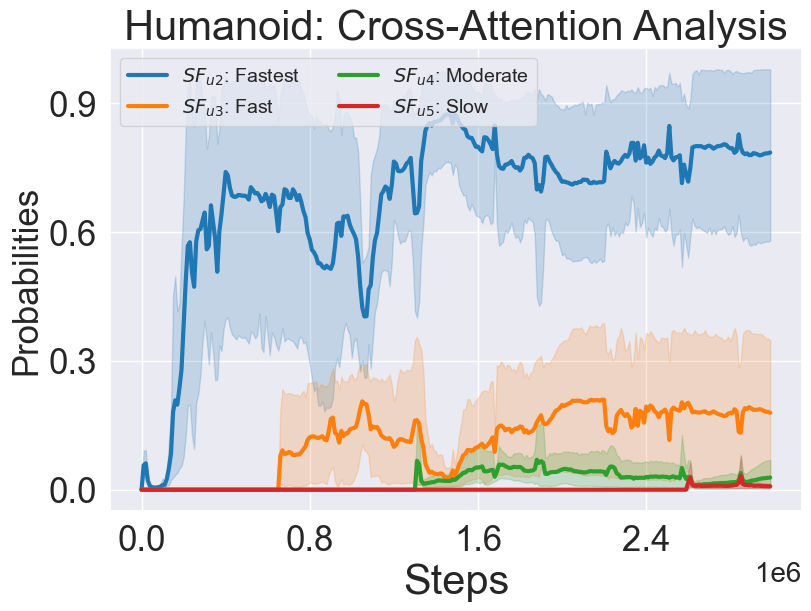

In [40]:
# Analysing the first attention mechanism
f, ax = plt.subplots(figsize=(8, 6), constrained_layout=True,)

# LEFT

sns.lineplot(
    x="eval/step",
    y="train/attention_distribution1_u_0_mean",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
    label=r"$SF_{u2}$: Fastest",
    color=colors_attention[0],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
)

sns.lineplot(
    x="eval/step",
    y="train/attention_distribution1_u_1_mean",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
    label=r"$SF_{u3}$: Fast",
    color=colors_attention[1],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
)

sns.lineplot(
    x="eval/step",
    y="train/attention_distribution1_u_2_mean",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
    label=r"$SF_{u4}$: Moderate",
    color=colors_attention[2],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
)

sns.lineplot(
    x="eval/step",
    y="train/attention_distribution1_u_3_mean",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
    label=r"$SF_{u5}$: Slow",
    color=colors_attention[3],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
)
#
# sns.lineplot(
#     x="eval/step",
#     y="train/attention_distribution1_u_4_mean",
#     data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
#     label="Slower",
#     color=colors_attention[4],
#     linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
# )
#
# sns.lineplot(
#     x="eval/step",
#     y="train/attention_distribution1_u_5_mean",
#     data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
#     label="Slowest",
#     color=colors_attention[5],
#     linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
# )
#
# sns.lineplot(
#     x="eval/step",
#     y="train/attention_distribution1_u_6_mean",
#     data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
#     label="Persistent",
#     color=colors_attention[6],
#     linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
# )

plt.title("Humanoid: Cross-Attention Analysis", fontsize=30)
plt.xlabel("Steps", fontsize=30)
plt.ylabel("Probabilities", fontsize=25)
plt.legend(loc="upper left", fontsize=14, ncol=2, frameon=True)
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
# plt.ylim(0, 1.2)  # Set y-axis limits for the first subplot
plt.gca().xaxis.get_offset_text().set_fontsize(20)
plt.gca().xaxis.set_major_locator(MaxNLocator(nbins=5))
plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=4))

filename = "sf_attention_dist_" + domain + "_" + cfg.mode
plt.savefig(filename + ".pdf")
plt.show()


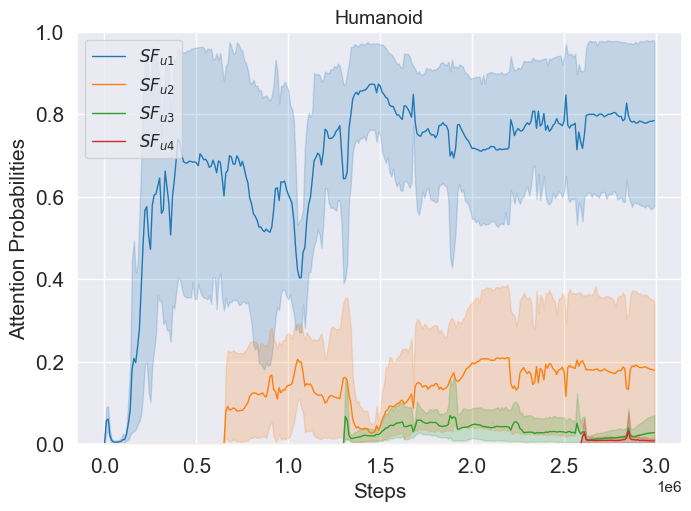

In [41]:
# Analysing the first attention mechanism
f, ax = plt.subplots(figsize=(6.8, 5), constrained_layout=True,)

# LEFT

sns.lineplot(
    x="eval/step",
    y="train/attention_distribution1_u_0_mean",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
    label=r"$SF_{u1}$",
    color=colors_attention[0],
    linewidth=1,  # use this value if there are 3 plots in one row. Else use 5
)

sns.lineplot(
    x="eval/step",
    y="train/attention_distribution1_u_1_mean",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
    label=r"$SF_{u2}$",
    color=colors_attention[1],
    linewidth=1,  # use this value if there are 3 plots in one row. Else use 5
)

sns.lineplot(
    x="eval/step",
    y="train/attention_distribution1_u_2_mean",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
    label=r"$SF_{u3}$",
    color=colors_attention[2],
    linewidth=1,  # use this value if there are 3 plots in one row. Else use 5
)

sns.lineplot(
    x="eval/step",
    y="train/attention_distribution1_u_3_mean",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
    label=r"$SF_{u4}$",
    color=colors_attention[3],
    linewidth=1,  # use this value if there are 3 plots in one row. Else use 5
    legend=False,
)
#
# sns.lineplot(
#     x="eval/step",
#     y="train/attention_distribution1_u_4_mean",
#     data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
#     label="Slower",
#     color=colors_attention[4],
#     linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
# )
#
# sns.lineplot(
#     x="eval/step",
#     y="train/attention_distribution1_u_5_mean",
#     data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
#     label="Slowest",
#     color=colors_attention[5],
#     linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
# )
#
# sns.lineplot(
#     x="eval/step",
#     y="train/attention_distribution1_u_6_mean",
#     data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
#     label="Persistent",
#     color=colors_attention[6],
#     linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
# )

plt.title("Humanoid", fontsize=14)
plt.xlabel("Steps", fontsize=15)
plt.ylabel("Attention Probabilities", fontsize=15)
plt.legend(loc="upper left", fontsize=12)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.ylim(0, 1.0)  # Set y-axis limits for the first subplot

filename = "sf_attention_dist_without_speed_" + domain + "_" + cfg.mode
plt.savefig(filename + ".pdf")
plt.show()


In [42]:
import matplotlib.pyplot as plt
import numpy as np

In [43]:
class NoisySineModulator:
    def __init__(self, period=25000, noise_std=0.05, min_val=0.75, max_val=1.25, phase=0.0, seed=97):
        """
        A noisy sine wave modulator for smooth, periodic scaling values.

        Args:
            period (int): Number of steps per full sine cycle.
            noise_std (float): Standard deviation of Gaussian noise added to sine.
            min_val (float): Minimum value of the scaled output.
            max_val (float): Maximum value of the scaled output.
            phase (float): Phase offset for sine wave (in radians), useful for offsetting mass vs friction.
        """
        self.period = period
        self.noise_std = noise_std
        self.min_val = min_val
        self.max_val = max_val
        self.phase = phase
        self.rng = np.random.default_rng(seed)

    def sample(self, step: int):
        """Return modulated value at a given training step."""
        sine_val = 0.5 * (np.sin(2 * np.pi * step / self.period + self.phase) + 1)
        noisy_val = sine_val + self.rng.normal(0.0, self.noise_std)
        noisy_val = np.clip(noisy_val, 0.0, 1.0)
        scaled_val = self.min_val + (self.max_val - self.min_val) * noisy_val
        return scaled_val


In [44]:
# Create modulators with different seeds
mass_mod = NoisySineModulator(period=250000, phase=0.0, seed=1, min_val=0.9, max_val=1.1)
friction_mod = NoisySineModulator(period=500000, phase=0.0, seed=2, min_val=0.7, max_val=1.3)

In [45]:
# Sample every 10,000 steps
steps = np.arange(0, 500_001, 10_000)
mass_vals = [mass_mod.sample(step) for step in steps]
friction_vals = [friction_mod.sample(step) for step in steps]

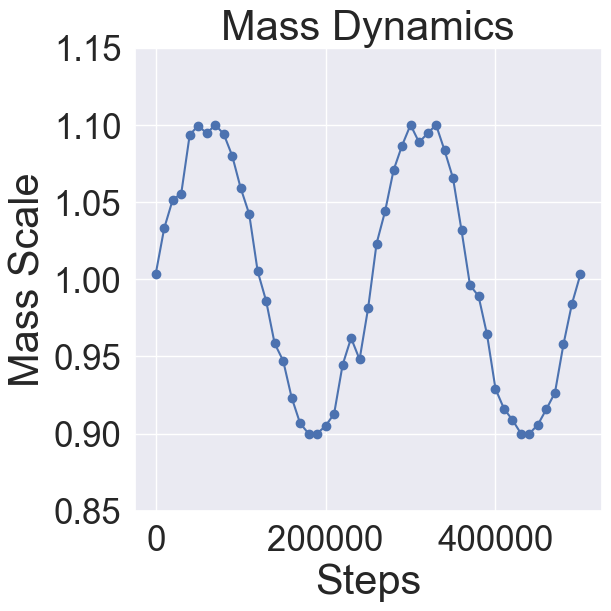

In [46]:
# Plot
plt.figure(figsize=(6, 6), constrained_layout=True)
plt.plot(steps, mass_vals, label="Mass Scale", marker='o')
# plt.plot(steps, friction_vals, label="Friction Scale (seed=2)", marker='x')
plt.title("Mass Dynamics", fontsize=30)
plt.xlabel("Steps", fontsize=30)
plt.ylabel("Mass Scale", fontsize=30)
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
plt.grid(True)
plt.legend([], [], frameon=False)
plt.ylim(0.85, 1.15)
# plt.ylim(0.5, 1.5)
# # Save the plot to a file
# plt.savefig("sine_wave_plot_friction.png", dpi=300, bbox_inches="tight")
ax.xaxis.get_offset_text().set_fontsize(20)
plt.gca().xaxis.set_major_locator(MaxNLocator(nbins=3))
plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=6))
plt.savefig("mass_dynamics_500k_humanoid.pdf")
plt.show()

In [47]:
api = wandb.Api()
project_name = "continual_rl" + domain + "_" + cfg.mode
entity = "crlmsf"
runs = api.runs(entity + "/" + project_name)

timescale_summary_list, timescale_config_list, timescale_name_list = [], [], []

logging.info("inside avg_episode_return")

num_of_runs = len(runs)
print("num_of_runs:", num_of_runs)

num_points_per_task = cfg.num_train_frames / cfg.eval_every_frames
# num_data_points_trained = (
#     num_points_per_task * cfg.num_unique_tasks * cfg.train.num_exposures
# )
# num_data_points_plotting = (
#     num_points_per_task * cfg.num_unique_tasks * cfg.num_exposures
# )

# print("num_data_points_trained: ", num_data_points_trained)
# print("num_data_points_plotting: ", num_data_points_plotting)

for idx, run in enumerate(runs):
    # .summary contains the output keys/values
    #  for metrics such as accuracy.
    #  We call ._json_dict to omit large files
    # summary_list.append(run.summary._json_dict)
    if idx % 10 == 0:
        print("idx:", idx)

    if "timescale" not in run.tags:
        continue

    if run.config["percentage_shifts_mass"] != percentage_shifts_mass[domain]:
        continue

    print(run.config["agent_name"])

    avg_episode_returns_history = run.scan_history(keys=["eval/episode_reward"])
    avg_episode_reward = [
        row["eval/episode_reward"] for row in avg_episode_returns_history
    ]

    steps_history = run.scan_history(keys=["eval/step"])

    steps = [row["eval/step"] for row in steps_history]

    # if len(steps) < num_data_points_plotting:
    #     print("len(steps) < num_data_points_plotting")
    #     print("seed: ", run.config["agents_seed"])
    #     print("agent_name: ", run.config["agent_name"])
    #     continue




    print("len(steps): ", len(steps))
    print("len(avg_episode_reward): ", len(avg_episode_reward))

    # combine steps and avg_episode_returns into a dictionary using train/steps and train/avg_episode_returns
    # as the keys.
    temp2 = dict()
    temp2["eval/step"] = steps
    temp2["eval/episode_reward"] = avg_episode_reward

    timescale_summary_list.append(temp2)
    del temp2

    # .config contains the hyperparameters.
    #  We remove special values that start with _.
    timescale_config_list.append(
        {k: v for k, v in run.config.items() if not k.startswith("_")}
    )

    # .name is the human-readable name of the run.
    timescale_name_list.append(run.name)

num_of_runs: 511
idx: 0
idx: 10
idx: 20
idx: 30
idx: 40
idx: 50
idx: 60
sf_simple_beakers_params
len(steps):  300
len(avg_episode_reward):  300
idx: 70
sf_simple_beakers_params
len(steps):  300
len(avg_episode_reward):  300
sf_simple_beakers_params
len(steps):  300
len(avg_episode_reward):  300
sf_simple_beakers_params
len(steps):  300
len(avg_episode_reward):  300
sf_simple_beakers_params
len(steps):  300
len(avg_episode_reward):  300
sf_simple_beakers_params
len(steps):  300
len(avg_episode_reward):  300
sf_simple_beakers_params
len(steps):  300
len(avg_episode_reward):  300
idx: 80
idx: 90
idx: 100
idx: 110
idx: 120
idx: 130
idx: 140
idx: 150
idx: 160
idx: 170
idx: 180
idx: 190
idx: 200
idx: 210
idx: 220
idx: 230
sf_simple_beakers_params
len(steps):  300
len(avg_episode_reward):  300
sf_simple_beakers_params
len(steps):  300
len(avg_episode_reward):  300
idx: 240
sf_simple_beakers_params
len(steps):  300
len(avg_episode_reward):  300
sf_simple_beakers_params
len(steps):  300
len(avg

In [48]:
timescale_runs_df = pd.DataFrame(
        {"summary": timescale_summary_list, "config": timescale_config_list, "name": timescale_name_list}
    )

# create a new column using agent_name
timescale_runs_df["agent_name"] = timescale_runs_df["config"].apply(lambda x: x["agent_name"])

# create a new column using agents_seed
timescale_runs_df["agent_seed"] = timescale_runs_df["config"].apply(lambda x: x["seed"])


# create a new column using agent_num_beakers
timescale_runs_df["agent_num_beakers"] = timescale_runs_df["config"].apply(lambda x: x["agent_num_beakers"])

In [49]:
# replace all "ddpg" in agent_name column with "TD3"
timescale_runs_df["agent_name"] = timescale_runs_df["agent_name"].replace(
    "sf_simple_beakers_params", agents_new_names["sf_simple_beakers_params"]
)

In [50]:
print(timescale_runs_df.columns.tolist())

['summary', 'config', 'name', 'agent_name', 'agent_seed', 'agent_num_beakers']


In [51]:
# remove the name and config column
timescale_runs_df = timescale_runs_df.drop(columns=["name", "config"])

# turn each key and its value into a column
timescale_runs_df = pd.concat(
    [timescale_runs_df.drop(["summary"], axis=1), timescale_runs_df["summary"].apply(pd.Series)], axis=1
)

# reset index
timescale_runs_df = timescale_runs_df.reset_index(drop=True)

print(timescale_runs_df)

# for each item in the column train/steps, get its corresponding value in the column train/avg_episode_returns
# and store it in a new row
timescale_runs_df = timescale_runs_df.explode(list(timescale_runs_df.columns[3:])).reset_index(drop=True)

print(timescale_runs_df.shape)

print("dataframe: ", timescale_runs_df)

        agent_name  agent_seed  agent_num_beakers  \
0   SF + SC (Ours)         679                  9   
1   SF + SC (Ours)         194                  9   
2   SF + SC (Ours)         582                  9   
3   SF + SC (Ours)         291                  9   
4   SF + SC (Ours)          97                  9   
5   SF + SC (Ours)         388                  9   
6   SF + SC (Ours)         485                  9   
7   SF + SC (Ours)         582                  6   
8   SF + SC (Ours)         291                  6   
9   SF + SC (Ours)         679                  6   
10  SF + SC (Ours)         194                  6   
11  SF + SC (Ours)         388                  6   
12  SF + SC (Ours)         485                  6   
13  SF + SC (Ours)          97                  6   
14  SF + SC (Ours)          97                  3   
15  SF + SC (Ours)         485                  3   
16  SF + SC (Ours)         388                  3   
17  SF + SC (Ours)         194                

In [52]:
# runs_df["eval/cumulative_episode_reward"] = runs_df["eval/episode_reward"].cumsum()

print(timescale_runs_df.columns)

timescale_runs_df["eval/episode_rewards_num"] = (
    timescale_runs_df["eval/episode_reward"]
      .astype(str)                 # ensure string for cleaning
      .str.replace(",", "", regex=False)  # drop thousands separators
      .str.strip()
      .pipe(pd.to_numeric, errors="coerce")  # -> floats; non-numeric -> NaN
)

timescale_runs_df = timescale_runs_df.sort_values(["agent_num_beakers", "agent_seed","eval/step"])

timescale_runs_df["eval/cumulative_rewards"] = (
    timescale_runs_df.groupby(["agent_num_beakers","agent_seed"])["eval/episode_rewards_num"].cumsum()
)

timescale_runs_df["episode_count"] = (
    timescale_runs_df.groupby(["agent_num_beakers","agent_seed", ]).cumcount() + 1
)

timescale_runs_df["norm_cum_reward"] = timescale_runs_df["eval/cumulative_rewards"] / timescale_runs_df["episode_count"]

timescale_runs_df["agent_name_pretty"] = timescale_runs_df["agent_name"].str.replace(" + ", "\n +", regex=False)

print(timescale_runs_df.columns)
# print(timescale_runs_df["agent_num_beakers","norm_cum_reward"])

Index(['agent_name', 'agent_seed', 'agent_num_beakers', 'eval/step',
       'eval/episode_reward'],
      dtype='object')
Index(['agent_name', 'agent_seed', 'agent_num_beakers', 'eval/step',
       'eval/episode_reward', 'eval/episode_rewards_num',
       'eval/cumulative_rewards', 'episode_count', 'norm_cum_reward',
       'agent_name_pretty'],
      dtype='object')


In [53]:
runs_df_sf_simple = runs_df[runs_df["agent_name"] == agents_new_names["sf_simple"]]

runs_df_sf_simple = runs_df_sf_simple[["agent_name", "agent_seed", "eval/step", "eval/episode_reward", "eval/cumulative_rewards", "episode_count", "norm_cum_reward", "agent_name_pretty", "eval/episode_rewards_num"]]

runs_df_sf_simple["agent_num_beakers"] = 0

timescale_runs_df = pd.concat([timescale_runs_df, runs_df_sf_simple], ignore_index=True)

print(timescale_runs_df)

          agent_name  agent_seed  agent_num_beakers  eval/step  \
0     SF + SC (Ours)          97                  3          0   
1     SF + SC (Ours)          97                  3      10000   
2     SF + SC (Ours)          97                  3      20000   
3     SF + SC (Ours)          97                  3      30000   
4     SF + SC (Ours)          97                  3      40000   
...              ...         ...                ...        ...   
7795              SF         485                  0  2950000.0   
7796              SF         485                  0  2960000.0   
7797              SF         485                  0  2970000.0   
7798              SF         485                  0  2980000.0   
7799              SF         485                  0  2990000.0   

     eval/episode_reward  eval/episode_rewards_num  eval/cumulative_rewards  \
0               1.134626                  1.134626                 1.134626   
1               0.899983                  0.89998

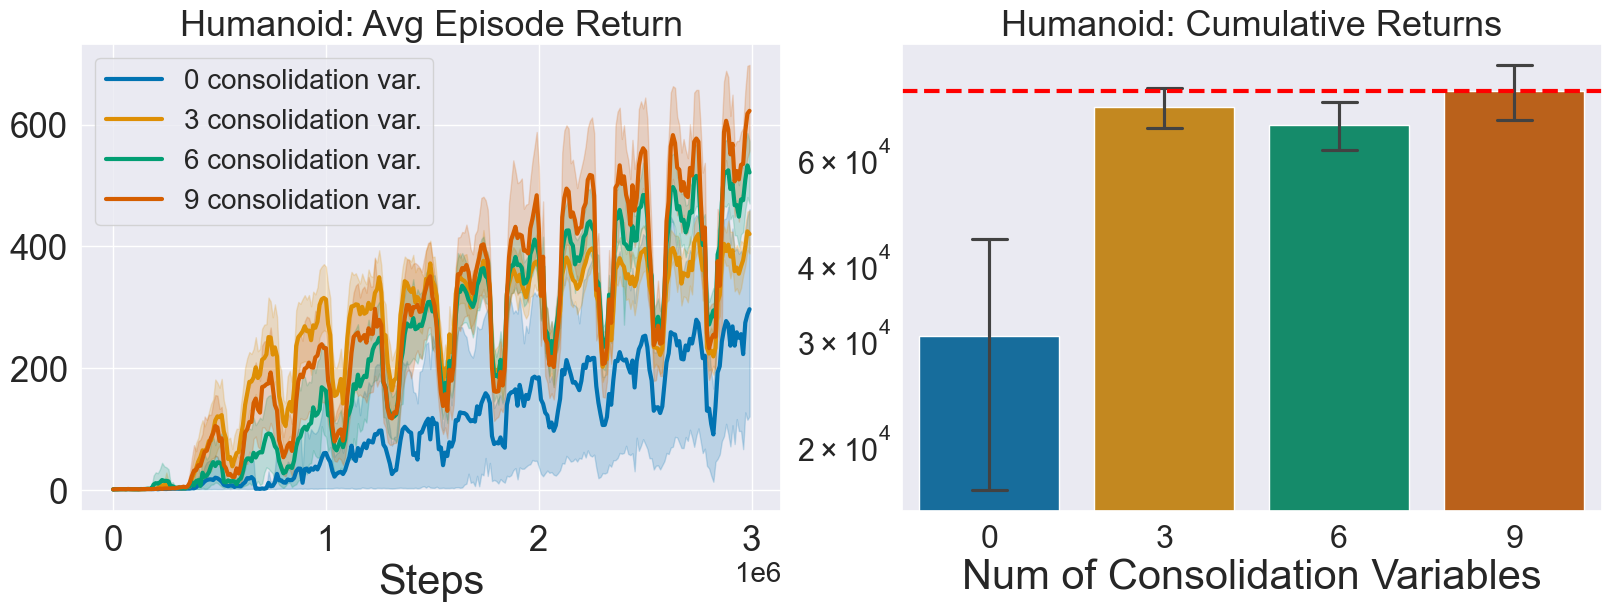

In [54]:
# Comparing with different number of beakers
fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

colors = sns.color_palette("colorblind", 4)

# LEFT

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple"]],
    label="0 consolidation var.",
    color=colors[0],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=timescale_runs_df[timescale_runs_df["agent_num_beakers"] == 3],
    label= "3 consolidation var.",
    color=colors[1],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=timescale_runs_df[timescale_runs_df["agent_num_beakers"] == 6],
    label= "6 consolidation var.",
    color=colors[2],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=timescale_runs_df[timescale_runs_df["agent_num_beakers"] == 9],
    label= "9 consolidation var.",
    color=colors[3],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

# RIGHT
# pick the last row per agent (largest step)
last_rows = timescale_runs_df.groupby(["agent_num_beakers", "agent_seed"], as_index=False).tail(1)

sns.barplot(data=last_rows, x="agent_num_beakers", y="eval/cumulative_rewards", ax=axes[1], errorbar="se", capsize=0.2, palette=colors, hue="agent_num_beakers", legend=False)

mean_val = last_rows[last_rows["agent_num_beakers"] == 9]["eval/cumulative_rewards"].mean()
axes[1].axhline(mean_val, color="red", linestyle="--", linewidth=3)

axes[0].set_title("Humanoid: Avg Episode Return", fontsize=26)
axes[0].set_xlabel("Steps", fontsize=30)
axes[0].set_ylabel("", fontsize=30)
axes[0].legend(loc="upper left", fontsize=20)
axes[0].tick_params(axis="x", labelsize=25)
axes[0].tick_params(axis="y", labelsize=25)
axes[0].xaxis.get_offset_text().set_fontsize(20)

axes[1].set_xlabel("Num of Consolidation Variables", fontsize=30)
axes[1].set_ylabel("", fontsize=30)
axes[1].set_title("Humanoid: Cumulative Returns", fontsize=26)
axes[1].tick_params(axis="x", labelsize=23)
axes[1].tick_params(axis="y", labelsize=22)
axes[1].set_yscale("log")
axes[1].tick_params(axis="y", labelsize=22, which="both")

filename = "num_beakers_analysis_" + domain + "_" + cfg.mode
plt.savefig(filename + ".pdf")
plt.show()


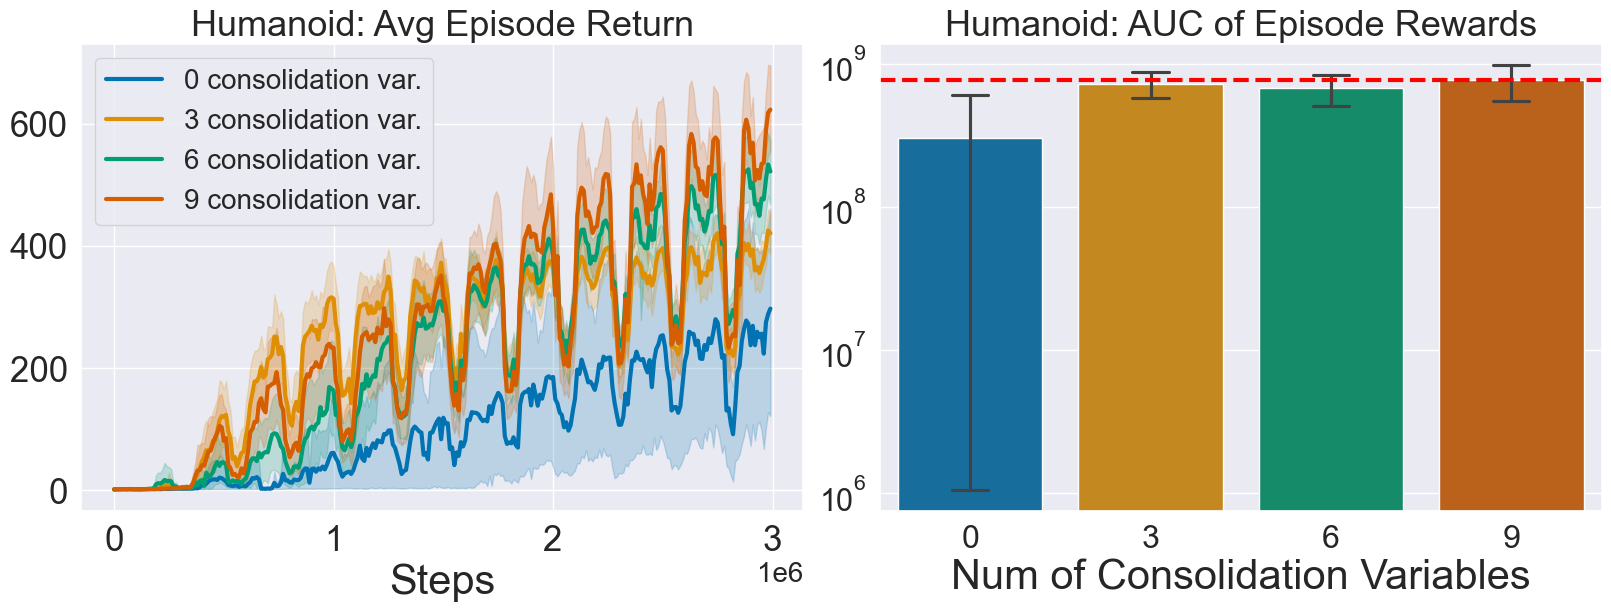

In [55]:
# Comparing with different number of beakers
fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

colors = sns.color_palette("colorblind", 4)

# LEFT

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple"]],
    label="0 consolidation var.",
    color=colors[0],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=timescale_runs_df[timescale_runs_df["agent_num_beakers"] == 3],
    label= "3 consolidation var.",
    color=colors[1],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=timescale_runs_df[timescale_runs_df["agent_num_beakers"] == 6],
    label= "6 consolidation var.",
    color=colors[2],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=timescale_runs_df[timescale_runs_df["agent_num_beakers"] == 9],
    label= "9 consolidation var.",
    color=colors[3],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

# RIGHT
# pick the last row per agent (largest step)
auc_df = (
    timescale_runs_df.groupby(["agent_num_beakers", "agent_seed"], group_keys=False)
      .apply(compute_auc, include_groups=False)
      .reset_index(name="AUC")
)

# agents_to_plot = ["TD3", "SF", "TD3 + SC", "SF + SC",]
# subset = auc_df[auc_df["agent_name"].isin(agents_to_plot)]

sns.barplot(
    data=auc_df,
    x="agent_num_beakers",
    y="AUC",
    errorbar="sd",   # std deviation across seeds
    capsize=0.2,
    hue="agent_num_beakers",
    palette=colors,
    ax=axes[1],
    legend=False,
)

mean_val = auc_df[auc_df["agent_num_beakers"] == 9]["AUC"].mean()
axes[1].axhline(mean_val, color="red", linestyle="--", linewidth=3)

axes[0].set_title("Humanoid: Avg Episode Return", fontsize=26)
axes[0].set_xlabel("Steps", fontsize=30)
axes[0].set_ylabel("", fontsize=30)
axes[0].legend(loc="upper left", fontsize=20)
axes[0].tick_params(axis="x", labelsize=25)
axes[0].tick_params(axis="y", labelsize=25)
axes[0].xaxis.get_offset_text().set_fontsize(20)

axes[1].set_xlabel("Num of Consolidation Variables", fontsize=30)
axes[1].set_ylabel("", fontsize=30)
axes[1].set_title("Humanoid: AUC of Episode Rewards", fontsize=26)
axes[1].tick_params(axis="x", labelsize=23)
axes[1].tick_params(axis="y", labelsize=22)
axes[1].set_yscale("log")
axes[1].tick_params(axis="y", labelsize=22, which="both")

filename = "num_beakers_analysis_with_auc_" + domain + "_" + cfg.mode
plt.savefig(filename + ".pdf")
plt.show()


/var/folders/60/3nwk45px1hj7s9fk4rz760qc0000gn/T/ipykernel_9254/3832242428.py:17: UserWarning: 
The palette list has fewer values (3) than needed (4) and will cycle, which may produce an uninterpretable plot.
  ax = sns.barplot(


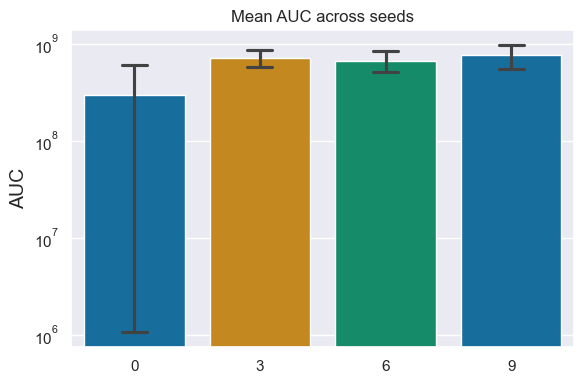

In [56]:
from scipy.integrate import trapezoid

colors = sns.color_palette("colorblind", 3)

def compute_auc(group):
    return trapezoid(group["eval/episode_reward"], group["eval/step"])
auc_df = (
    timescale_runs_df.groupby(["agent_num_beakers", "agent_seed"], group_keys=False)
      .apply(compute_auc, include_groups=False)
      .reset_index(name="AUC")
)

# agents_to_plot = ["TD3", "SF", "TD3 + SC", "SF + SC",]
# subset = auc_df[auc_df["agent_name"].isin(agents_to_plot)]

plt.figure(figsize=(6,4))
ax = sns.barplot(
    data=auc_df,
    x="agent_num_beakers",
    y="AUC",
    errorbar="sd",   # std deviation across seeds
    capsize=0.2,
    hue="agent_num_beakers",
    legend=False,
    palette=colors,

)
ax.set_yscale("log")
plt.title("Mean AUC across seeds")
plt.ylabel("AUC", fontsize=14)
plt.xlabel("")
plt.tight_layout()
filename = "num_beakers_AUC_analysis_" + domain + "_" + cfg.mode
plt.savefig(filename + ".pdf")
plt.show()

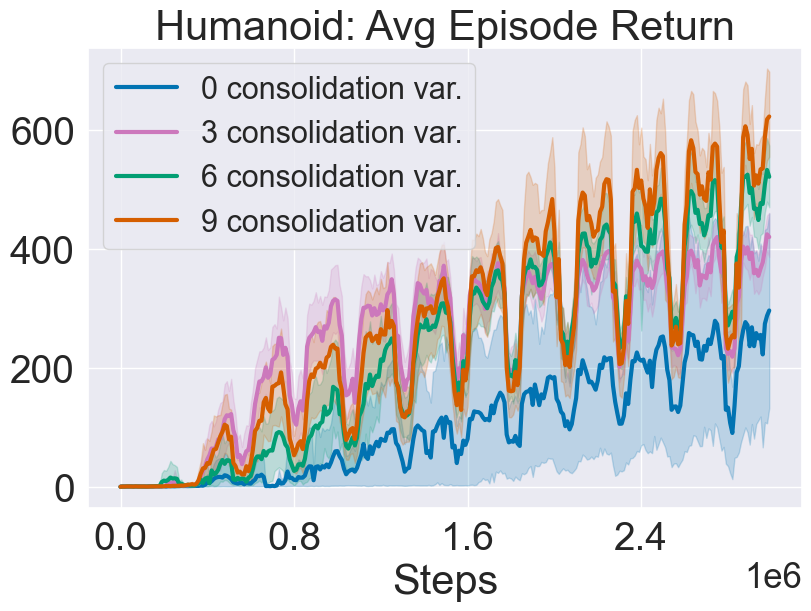

In [57]:
from scipy.integrate import trapezoid

colors = sns.color_palette("colorblind", 6)

def compute_auc(group):
    return trapezoid(group["eval/episode_reward"], group["eval/step"])
auc_df = (
    timescale_runs_df.groupby(["agent_num_beakers", "agent_seed"], group_keys=False)
      .apply(compute_auc, include_groups=False)
      .reset_index(name="AUC")
)

# agents_to_plot = ["TD3", "SF", "TD3 + SC", "SF + SC",]
# subset = auc_df[auc_df["agent_name"].isin(agents_to_plot)]

plt.close()
fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=timescale_runs_df[timescale_runs_df["agent_num_beakers"] == 0],
    label= "0 consolidation var.",
    color=colors[0],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=timescale_runs_df[timescale_runs_df["agent_num_beakers"] == 3],
    label= "3 consolidation var.",
    color=colors[4],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=timescale_runs_df[timescale_runs_df["agent_num_beakers"] == 6],
    label= "6 consolidation var.",
    color=colors[2],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=timescale_runs_df[timescale_runs_df["agent_num_beakers"] == 9],
    label= "9 consolidation var.",
    color=colors[3],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
)
# ax.set_yscale("log")
plt.title("Humanoid: Avg Episode Return", fontsize=30)
plt.ylabel("", fontsize=14)
plt.xlabel("Steps", fontsize=30)
plt.legend(loc="upper left", fontsize=22)
# plt.legend().set_visible(False)
plt.xticks(fontsize=28)
plt.yticks(fontsize=28)
plt.gca().xaxis.get_offset_text().set_fontsize(25)
plt.gca().xaxis.set_major_locator(MaxNLocator(nbins=5))
plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=5))


filename = "num_beakers_episode_return_analysis_" + domain + "_" + cfg.mode
plt.savefig(filename + ".pdf")
plt.show()

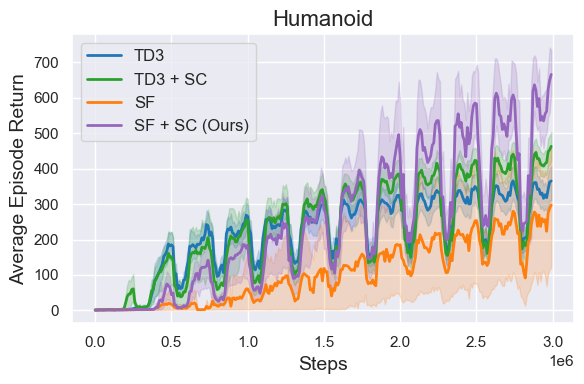

In [58]:


# agents_to_plot = ["TD3", "SF", "TD3 + SC", "SF + SC",]
# subset = auc_df[auc_df["agent_name"].isin(agents_to_plot)]

plt.figure(figsize=(6,4))

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg"]],
    label=agents_new_names["ddpg"],
    color=color_code[agents_new_names["ddpg"]],
    linewidth=2,  # use this value if there are 3 plots in one row. Else use 5
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_beakers_params_continuous"]],
    label=agents_new_names["ddpg_beakers_params_continuous"],
    color=color_code[agents_new_names["ddpg_beakers_params_continuous"]],
    linewidth=2,  # use this value if there are 3 plots in one row. Else use 5
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple"]],
    label=agents_new_names["sf_simple"],
    color=color_code[agents_new_names["sf_simple"]],
    linewidth=2,  # use this value if there are 3 plots in one row. Else use 5
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params"]],
    label=agents_new_names["sf_simple_beakers_params"],
    color=color_code[agents_new_names["sf_simple_beakers_params"]],
    linewidth=2,  # use this value if there are 3 plots in one row. Else use 5
)

ax.set_yscale("log")
plt.title("Humanoid", fontsize=16)
plt.ylabel("Average Episode Return", fontsize=14)
plt.xlabel("Steps", fontsize=14)
plt.tight_layout()
plt.legend(loc="upper left", fontsize=12)
filename = "q_sc_vs_sf_sc_episode_return_analysis_" + domain + "_" + cfg.mode
plt.savefig(filename + ".pdf")
plt.show()

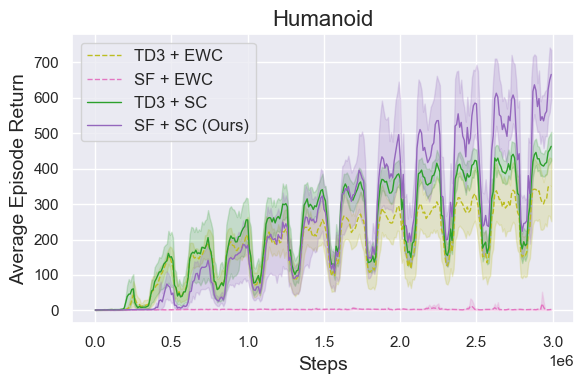

In [59]:


# agents_to_plot = ["TD3", "SF", "TD3 + SC", "SF + SC",]
# subset = auc_df[auc_df["agent_name"].isin(agents_to_plot)]

plt.figure(figsize=(6,4))


sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_online_ewc"]],
    label=agents_new_names["ddpg_online_ewc"],
    color=color_code[agents_new_names["ddpg_online_ewc"]],
    linewidth=1,  # use this value if there are 3 plots in one row. Else use 5
    linestyle='--',
    dashes=(1, 1)   # 2 on, 2 off -> fine dash
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_online_ewc"]],
    label=agents_new_names["sf_online_ewc"],
    color=color_code[agents_new_names["sf_online_ewc"]],
    linewidth=1,  # use this value if there are 3 plots in one row. Else use 5
    linestyle='--',
    dashes=(1, 1)   # 2 on, 2 off -> fine dash
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_beakers_params_continuous"]],
    label=agents_new_names["ddpg_beakers_params_continuous"],
    color=color_code[agents_new_names["ddpg_beakers_params_continuous"]],
    linewidth=1,  # use this value if there are 3 plots in one row. Else use 5
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params"]],
    label=agents_new_names["sf_simple_beakers_params"],
    color=color_code[agents_new_names["sf_simple_beakers_params"]],
    linewidth=1,  # use this value if there are 3 plots in one row. Else use 5
)


ax.set_yscale("log")
plt.title("Humanoid", fontsize=16)
plt.ylabel("Average Episode Return", fontsize=14)
plt.xlabel("Steps", fontsize=14)
plt.tight_layout()
plt.legend(loc="upper left", fontsize=12)
filename = "ewc_vs_sc_episode_return_analysis_" + domain + "_" + cfg.mode
plt.savefig(filename + ".pdf")
plt.show()

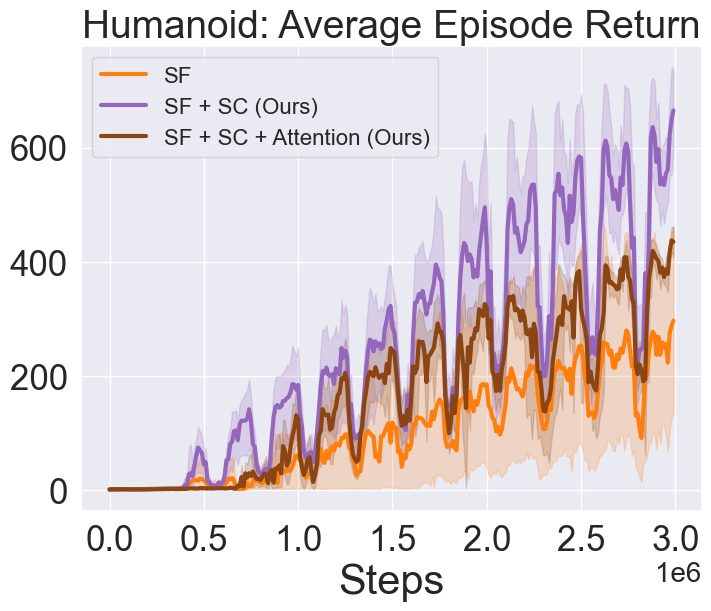

In [60]:
# Using attention to improve memory recall
plt.figure(figsize=(7, 6), constrained_layout=True)

# RIGHT
# sns.lineplot(
#     x="eval/step",
#     y="eval/episode_reward",
#     data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg"]],
#     label=agents_new_names["ddpg"],
#     color=color_code[agents_new_names["ddpg"]],
#     linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
# )
#




# sns.lineplot(
#     x="eval/step",
#     y="eval/episode_reward",
#     data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_beakers_params_continuous"]],
#     label=agents_new_names["ddpg_beakers_params_continuous"],
#     color=color_code[agents_new_names["ddpg_beakers_params_continuous"]],
#     linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
# )

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple"]],
    label=agents_new_names["sf_simple"],
    color=color_code[agents_new_names["sf_simple"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params"]],
    label=agents_new_names["sf_simple_beakers_params"],
    color=color_code[agents_new_names["sf_simple_beakers_params"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
    label=agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"],
    color=color_code[agents_new_names["sf_simple_beakers_params_continuous_attention_diff_unique"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
)

# fig.suptitle("Can cross-attention improve memory recall?", fontsize=18)

# axes[0].set_xlabel("Agent", fontsize=14)
# axes[0].set_ylabel("Total Cumulative Return", fontsize=14)
# # axes[0].set_title("Total Cumulative Returns (Evaluation)", fontsize=16)
# axes[0].tick_params(axis="x", labelsize=15)
# axes[0].tick_params(axis="y", labelsize=18)
# axes[0].set_yscale("log")

plt.title("Humanoid: Average Episode Return", fontsize=28)
plt.ylabel("", fontsize=14)
plt.xlabel("Steps", fontsize=30)
plt.legend(loc="upper left", fontsize=16)
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
plt.gca().xaxis.get_offset_text().set_fontsize(20)
plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=5))

filename = "avg_episode_reward_attention_sf_" + domain + "_" + cfg.mode
plt.savefig(filename + ".pdf")
plt.show()


/var/folders/60/3nwk45px1hj7s9fk4rz760qc0000gn/T/ipykernel_9254/1707163341.py:102: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["agent_name_pretty"] = subset["agent_name"].str.replace(" + ", "\n +", regex=False)
/var/folders/60/3nwk45px1hj7s9fk4rz760qc0000gn/T/ipykernel_9254/1707163341.py:104: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["agent_name_pretty"] = pd.Categorical(subset["agent_name_pretty"], categories=[name.replace(" + ", "\n +") for name in agents_to_plot], ordered=True)


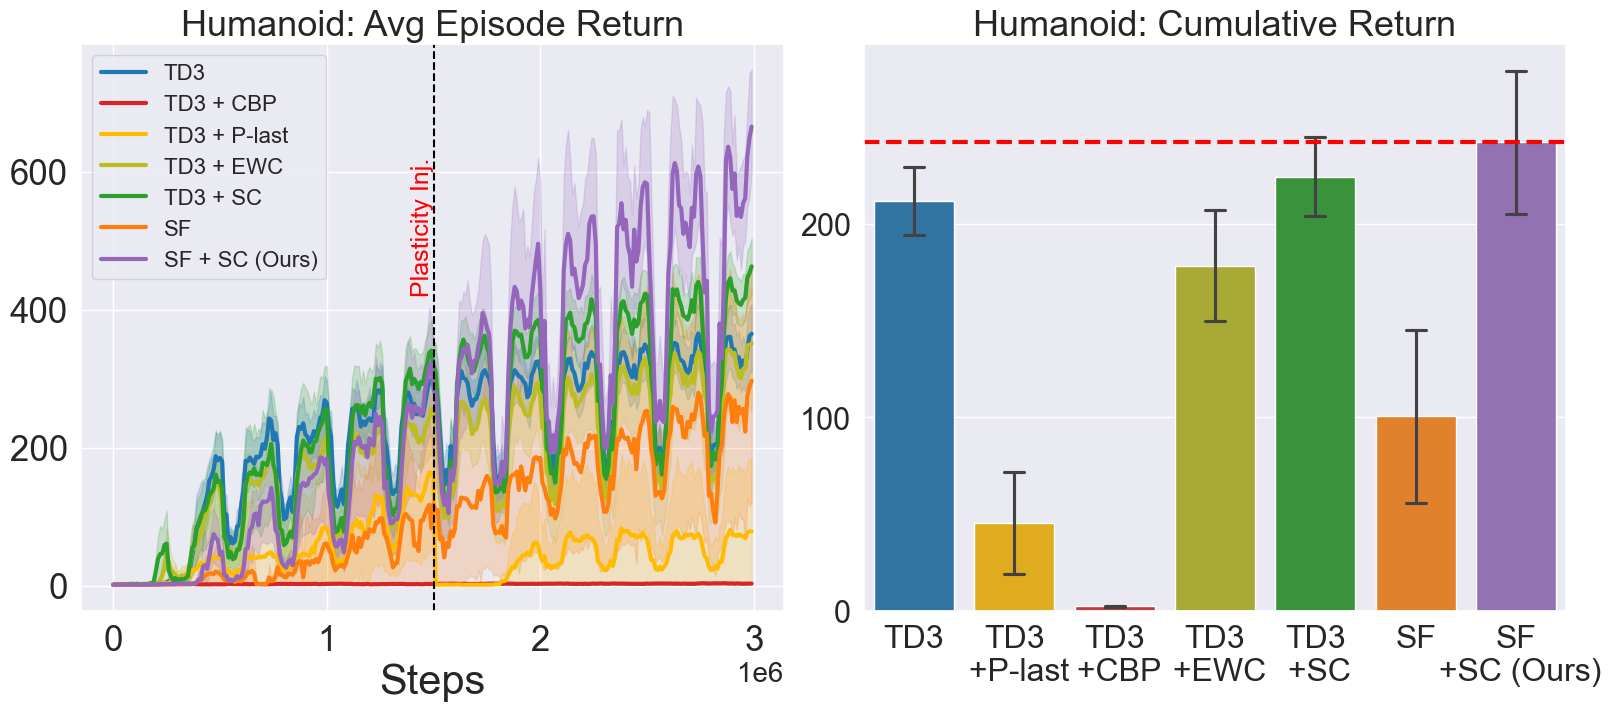

In [61]:
# Plot for Plasticity-Stability Analysis

from matplotlib.ticker import MaxNLocator, LogLocator

fig, axes = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)
# LEFT

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg"]],
    label=agents_new_names["ddpg"],
    color=color_code[agents_new_names["ddpg"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
     ax=axes[0],
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_continual_backprop"]],
    label=agents_new_names["ddpg_continual_backprop"],
    color=color_code[agents_new_names["ddpg_continual_backprop"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)


sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_plasticity_injection_last_layer"]],
    label=agents_new_names["ddpg_plasticity_injection_last_layer"],
    color=color_code[agents_new_names["ddpg_plasticity_injection_last_layer"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0]
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_online_ewc"]],
    label=agents_new_names["ddpg_online_ewc"],
    color=color_code[agents_new_names["ddpg_online_ewc"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_beakers_params_continuous"]],
    label=agents_new_names["ddpg_beakers_params_continuous"],
    color=color_code[agents_new_names["ddpg_beakers_params_continuous"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple"]],
    label=agents_new_names["sf_simple"],
    color=color_code[agents_new_names["sf_simple"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params"]],
    label=agents_new_names["sf_simple_beakers_params"],
    color=color_code[agents_new_names["sf_simple_beakers_params"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

xline = 1500000
ymin, ymax = axes[0].get_ylim()

axes[0].axvline(x=xline, color="black", linestyle="--", linewidth=1.5)
axes[0].text(
    xline,                      # x position (same as line)
    ymin + 0.8* (ymax - ymin),   # 40% above the bottom,
    "Plasticity Inj.",
    rotation=90,                # vertical text
    color="red",
    ha="right", va="top",       # horizontal/vertical alignment
    fontsize=18
)


# Right
last_rows = runs_df.groupby(["agent_name", "agent_seed"], as_index=False).tail(1)
agents_to_plot = ["TD3", "TD3 + P-last", "TD3 + CBP", "TD3 + EWC", "TD3 + SC", "SF", "SF + SC (Ours)"]
# agents_to_plot = ["TD3", "TD3 + CBP", "TD3 + EWC", "TD3 + SC", "SF + SC (Ours)"]
subset = last_rows[last_rows["agent_name"].isin(agents_to_plot)]

# subset.loc[subset["agent_name_pretty"] == "SF\n +SC (Ours)", "agent_name_pretty"] = "SF\n +SC \n(Ours)"

subset["agent_name_pretty"] = subset["agent_name"].str.replace(" + ", "\n +", regex=False)

subset["agent_name_pretty"] = pd.Categorical(subset["agent_name_pretty"], categories=[name.replace(" + ", "\n +") for name in agents_to_plot], ordered=True)

sns.barplot(data=subset, x="agent_name_pretty", y="norm_cum_reward", palette=color_code, ax=axes[1], errorbar="se", capsize=0.2, hue="agent_name_pretty")

mean_val = last_rows[last_rows["agent_name"] == agents_new_names["sf_simple_beakers_params"]]["norm_cum_reward"].mean()
axes[1].axhline(mean_val, color="red", linestyle="--", linewidth=3)

# fig.suptitle("Consolidating Q-values vs SFs under Mass Changes", fontsize=18)

axes[0].set_title("Humanoid: Avg Episode Return", fontsize=26)
axes[0].set_xlabel("Steps", fontsize=30)
axes[0].set_ylabel("", fontsize=30)
axes[0].legend(loc="upper left", fontsize=16, ncol=1)
axes[0].tick_params(axis="x", labelsize=25)
axes[0].tick_params(axis="y", labelsize=25)
axes[0].xaxis.get_offset_text().set_fontsize(20)
axes[0].yaxis.set_major_locator(MaxNLocator(nbins=5))

axes[1].set_xlabel("", fontsize=14)
axes[1].set_ylabel("", fontsize=14)
axes[1].set_title("Humanoid: Cumulative Return", fontsize=26)
axes[1].tick_params(axis="x", labelsize=23)
axes[1].tick_params(axis="y", labelsize=22, which="both")
# axes[1].set_yscale("log")
axes[1].yaxis.set_major_locator(MaxNLocator(nbins=3))
axes[1].yaxis.set_minor_locator(LogLocator(base=10.0, subs=[]))     # no minor ticks

filename = "plasticity_stability_analysis_with_sf_" + domain + "_" + cfg.mode
fig.savefig(filename + ".pdf", bbox_inches="tight")
plt.show()


/var/folders/60/3nwk45px1hj7s9fk4rz760qc0000gn/T/ipykernel_9254/2200039865.py:106: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["agent_name_pretty"] = subset["agent_name"].str.replace(" + ", "\n +", regex=False)
/var/folders/60/3nwk45px1hj7s9fk4rz760qc0000gn/T/ipykernel_9254/2200039865.py:107: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["agent_name_pretty"] = subset["agent_name_pretty"].str.replace(
/var/folders/60/3nwk45px1hj7s9fk4rz760qc0000gn/T/ipykernel_9254/2200039865.py:119: SettingWi

['SF', 'SF\n +SC \n(Ours)', 'TD3', 'TD3\n +CBP', 'TD3\n +EWC', 'TD3\n +P-last', 'TD3\n +SC']
Categories (7, object): ['TD3' < 'TD3\n +P-last' < 'TD3\n +CBP' < 'TD3\n +EWC' < 'TD3\n +SC' < 'SF' < 'SF\n +SC \n(Ours)']


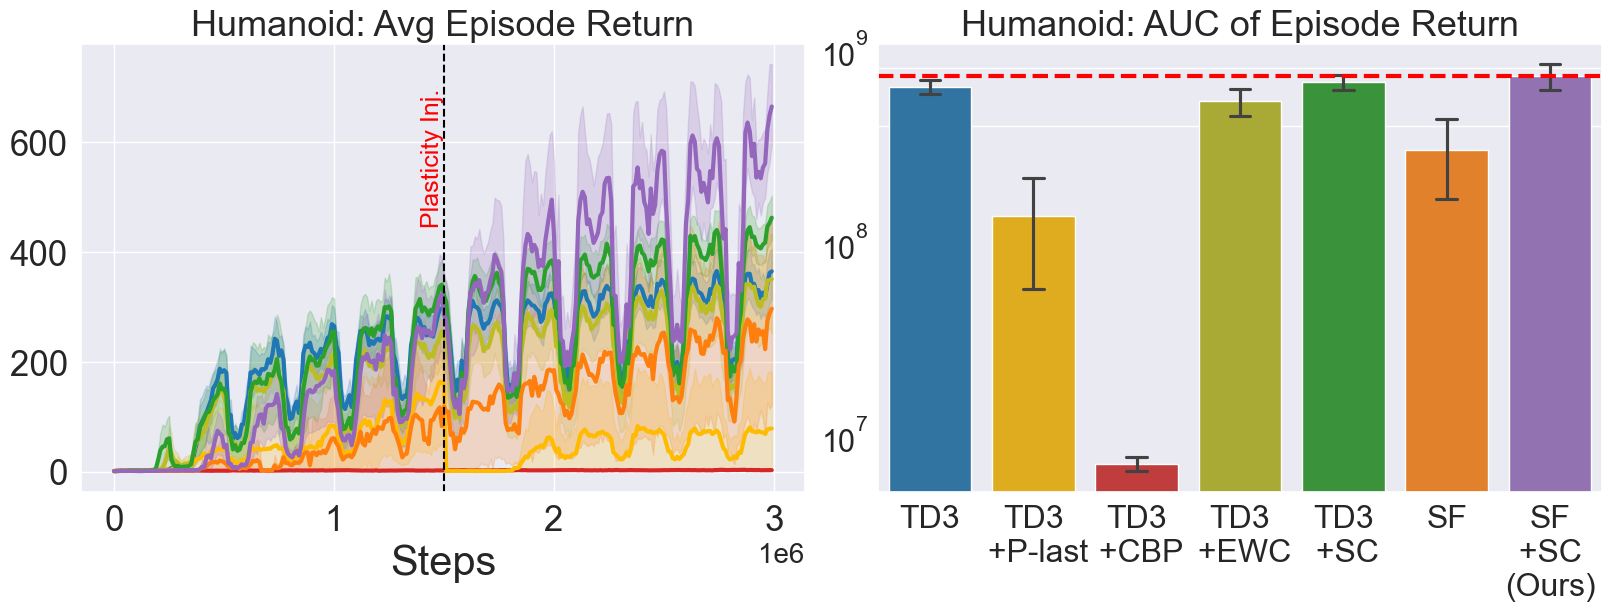

In [67]:
# Plot for Plasticity-Stability Analysis

from matplotlib.ticker import MaxNLocator, LogLocator

fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
# LEFT

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg"]],
    label=agents_new_names["ddpg"],
    color=color_code[agents_new_names["ddpg"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
     ax=axes[0],
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_continual_backprop"]],
    label=agents_new_names["ddpg_continual_backprop"],
    color=color_code[agents_new_names["ddpg_continual_backprop"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)


sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_plasticity_injection_last_layer"]],
    label=agents_new_names["ddpg_plasticity_injection_last_layer"],
    color=color_code[agents_new_names["ddpg_plasticity_injection_last_layer"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0]
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_online_ewc"]],
    label=agents_new_names["ddpg_online_ewc"],
    color=color_code[agents_new_names["ddpg_online_ewc"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_beakers_params_continuous"]],
    label=agents_new_names["ddpg_beakers_params_continuous"],
    color=color_code[agents_new_names["ddpg_beakers_params_continuous"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple"]],
    label=agents_new_names["sf_simple"],
    color=color_code[agents_new_names["sf_simple"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params"]],
    label=agents_new_names["sf_simple_beakers_params"],
    color=color_code[agents_new_names["sf_simple_beakers_params"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

xline = 1500000
ymin, ymax = axes[0].get_ylim()

axes[0].axvline(x=xline, color="black", linestyle="--", linewidth=1.5)
axes[0].text(
    xline,                      # x position (same as line)
    ymin + 0.9* (ymax - ymin),   # 40% above the bottom,
    "Plasticity Inj.",
    rotation=90,                # vertical text
    color="red",
    ha="right", va="top",       # horizontal/vertical alignment
    fontsize=18
)


# Right
def compute_auc(group):
    return trapezoid(group["eval/episode_reward"], group["eval/step"])
auc_df = (
    runs_df.groupby(["agent_name", "agent_seed"], group_keys=False)
      .apply(compute_auc, include_groups=False)
      .reset_index(name="AUC")
)

# last_rows = runs_df.groupby(["agent_name", "agent_seed"], as_index=False).tail(1)
agents_to_plot = ["TD3", "TD3 + P-last", "TD3 + CBP", "TD3 + EWC", "TD3 + SC", "SF", "SF + SC (Ours)"]
subset = auc_df[auc_df["agent_name"].isin(agents_to_plot)]
subset["agent_name_pretty"] = subset["agent_name"].str.replace(" + ", "\n +", regex=False)
subset["agent_name_pretty"] = subset["agent_name_pretty"].str.replace(
    "SF\n +SC (Ours)", "SF\n +SC \n(Ours)", regex=False
)
# agents_to_plot is defined earlier
agents_order = [name.replace(" + ", "\n +") for name in agents_to_plot]
agents_order[-1] = "SF\n +SC \n(Ours)"


# Ensure subset has the pretty labels and exact category order
# subset["agent_name_pretty"] = subset["agent_name"].str.replace(" + ", "\n +", regex=False)
# subset.loc[subset["agent_name_pretty"] == "SF\n +SC (Ours)", "agent_name_pretty"] = "SF\n + SC \n(Ours)"

subset["agent_name_pretty"] = pd.Categorical(subset["agent_name_pretty"],
                                             categories=agents_order,
                                             ordered=True)
print(subset["agent_name_pretty"].unique())

ax = sns.barplot(data=subset, x="agent_name_pretty", y="AUC", palette=color_code, errorbar="se", capsize=0.2, hue="agent_name_pretty")

mean_val = subset[subset["agent_name"] == agents_new_names["sf_simple_beakers_params"]]["AUC"].mean()
ax.axhline(mean_val, color="red", linestyle="--", linewidth=3)

# fig.suptitle("Consolidating Q-values vs SFs under Mass Changes", fontsize=18)

axes[0].set_title("Humanoid: Avg Episode Return", fontsize=26)
axes[0].set_xlabel("Steps", fontsize=30)
axes[0].set_ylabel("", fontsize=30)
# axes[0].legend(loc="upper left", fontsize=16, ncol=1)
axes[0].legend().set_visible(False)
axes[0].tick_params(axis="x", labelsize=25)
axes[0].tick_params(axis="y", labelsize=25)
axes[0].xaxis.get_offset_text().set_fontsize(20)
axes[0].yaxis.set_major_locator(MaxNLocator(nbins=5))

axes[1].set_xlabel("", fontsize=14)
axes[1].set_ylabel("", fontsize=26)
axes[1].set_title("Humanoid: AUC of Episode Return", fontsize=26)
axes[1].tick_params(axis="x", labelsize=23)
axes[1].tick_params(axis="y", labelsize=22, which="both")
axes[1].set_yscale("log")
axes[1].yaxis.set_major_locator(MaxNLocator(nbins=3))
axes[1].yaxis.set_minor_locator(LogLocator(base=10.0, subs=[]))     # no minor ticks
axes[1].yaxis.get_offset_text().set_visible(False)


filename = "plasticity_stability_analysis_with_sf_" + domain + "_" + cfg.mode
fig.savefig(filename + ".pdf", bbox_inches="tight")
plt.show()


/var/folders/60/3nwk45px1hj7s9fk4rz760qc0000gn/T/ipykernel_9254/3478460376.py:97: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["agent_name_pretty"] = subset["agent_name"].str.replace(" + ", "\n +", regex=False)


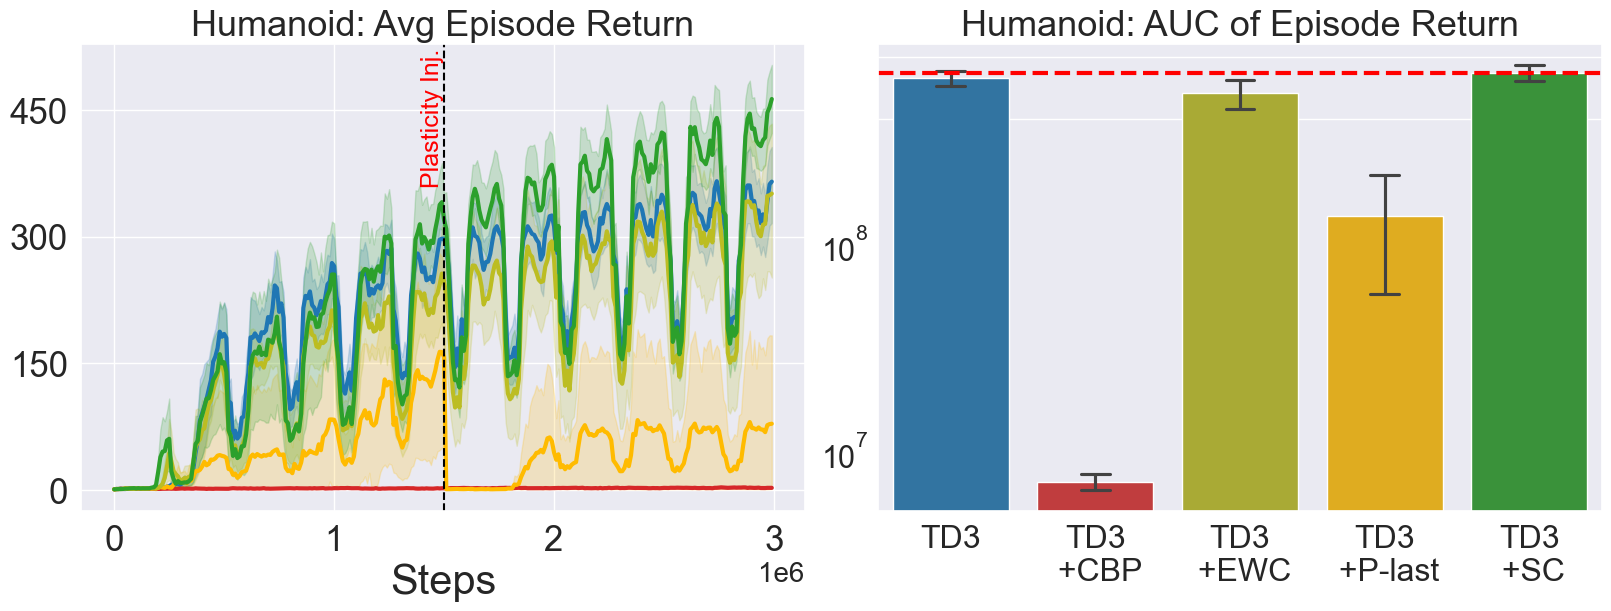

In [63]:
# Plot for Plasticity-Stability Analysis

from matplotlib.ticker import MaxNLocator, LogLocator

fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)
# LEFT

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg"]],
    label=agents_new_names["ddpg"],
    color=color_code[agents_new_names["ddpg"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
     ax=axes[0],
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_continual_backprop"]],
    label=agents_new_names["ddpg_continual_backprop"],
    color=color_code[agents_new_names["ddpg_continual_backprop"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)


sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_plasticity_injection_last_layer"]],
    label=agents_new_names["ddpg_plasticity_injection_last_layer"],
    color=color_code[agents_new_names["ddpg_plasticity_injection_last_layer"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0]
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_online_ewc"]],
    label=agents_new_names["ddpg_online_ewc"],
    color=color_code[agents_new_names["ddpg_online_ewc"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_beakers_params_continuous"]],
    label=agents_new_names["ddpg_beakers_params_continuous"],
    color=color_code[agents_new_names["ddpg_beakers_params_continuous"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
    ax=axes[0],
)

# sns.lineplot(
#     x="eval/step",
#     y="eval/episode_reward",
#     data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params"]],
#     label=agents_new_names["sf_simple_beakers_params"],
#     color=color_code[agents_new_names["sf_simple_beakers_params"]],
#     linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
#     ax=axes[0],
# )

xline = 1500000
ymin, ymax = axes[0].get_ylim()

axes[0].axvline(x=xline, color="black", linestyle="--", linewidth=1.5)
axes[0].text(
    xline,                      # x position (same as line)
    ymin + 0.99* (ymax - ymin),   # 40% above the bottom,
    "Plasticity Inj.",
    rotation=90,                # vertical text
    color="red",
    ha="right", va="top",       # horizontal/vertical alignment
    fontsize=18
)


# Right
def compute_auc(group):
    return trapezoid(group["eval/episode_reward"], group["eval/step"])
auc_df = (
    runs_df.groupby(["agent_name", "agent_seed"], group_keys=False)
      .apply(compute_auc, include_groups=False)
      .reset_index(name="AUC")
)

# last_rows = runs_df.groupby(["agent_name", "agent_seed"], as_index=False).tail(1)
agents_to_plot = ["TD3", "TD3 + P-last", "TD3 + CBP", "TD3 + EWC", "TD3 + SC"]
# agents_to_plot = ["TD3", "TD3 + CBP", "TD3 + EWC", "TD3 + SC", "SF + SC (Ours)"]
subset = auc_df[auc_df["agent_name"].isin(agents_to_plot)]
subset["agent_name_pretty"] = subset["agent_name"].str.replace(" + ", "\n +", regex=False)
subset.loc[subset["agent_name_pretty"] == "SF\n +SC (Ours)", "agent_name_pretty"] = "SF\n +SC \n(Ours)"
ax = sns.barplot(data=subset, x="agent_name_pretty", y="AUC", palette=color_code, errorbar="se", capsize=0.2, hue="agent_name_pretty")

mean_val = subset[subset["agent_name"] == agents_new_names["ddpg_beakers_params_continuous"]]["AUC"].mean()
axes[1].axhline(mean_val, color="red", linestyle="--", linewidth=3)

# fig.suptitle("Consolidating Q-values vs SFs under Mass Changes", fontsize=18)

axes[0].set_title("Humanoid: Avg Episode Return", fontsize=26)
axes[0].set_xlabel("Steps", fontsize=30)
axes[0].set_ylabel("", fontsize=30)
# axes[0].legend(loc="upper left", fontsize=16, ncol=2)
axes[0].legend().set_visible(False)
axes[0].tick_params(axis="x", labelsize=25)
axes[0].tick_params(axis="y", labelsize=25)
axes[0].xaxis.get_offset_text().set_fontsize(20)
axes[0].yaxis.set_major_locator(MaxNLocator(nbins=5))

axes[1].set_xlabel("", fontsize=14)
axes[1].set_ylabel("", fontsize=26)
axes[1].set_title("Humanoid: AUC of Episode Return", fontsize=26)
axes[1].tick_params(axis="x", labelsize=23)
axes[1].tick_params(axis="y", labelsize=22, which="both")
axes[1].set_yscale("log")
axes[1].yaxis.set_major_locator(MaxNLocator(nbins=3))
axes[1].yaxis.set_minor_locator(LogLocator(base=10.0, subs=[]))     # no minor ticks
axes[1].yaxis.get_offset_text().set_visible(False)


filename = "plasticity_stability_analysis_with_only_qvals_" + domain + "_" + cfg.mode
fig.savefig(filename + ".pdf", bbox_inches="tight")
plt.show()


/var/folders/60/3nwk45px1hj7s9fk4rz760qc0000gn/T/ipykernel_9254/1546447545.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset["agent_name_pretty"] = subset["agent_name"].str.replace(" + ", "\n +", regex=False)


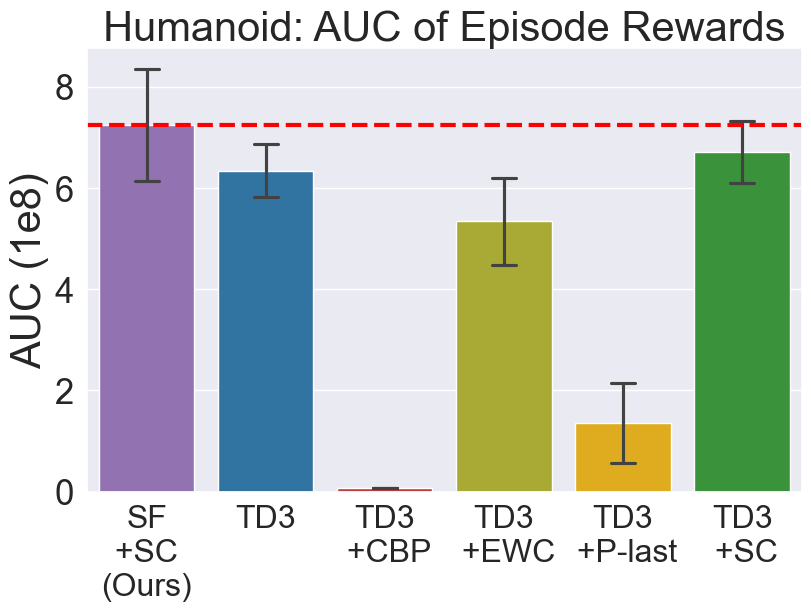

In [64]:
from scipy.integrate import trapezoid

colors = sns.color_palette("colorblind", 3)
plt.figure(figsize=(8,6), constrained_layout=True)

def compute_auc(group):
    return trapezoid(group["eval/episode_reward"], group["eval/step"])
auc_df = (
    runs_df.groupby(["agent_name", "agent_seed"], group_keys=False)
      .apply(compute_auc, include_groups=False)
      .reset_index(name="AUC")
)

# last_rows = runs_df.groupby(["agent_name", "agent_seed"], as_index=False).tail(1)
agents_to_plot = ["TD3", "TD3 + P-last", "TD3 + CBP", "TD3 + EWC", "TD3 + SC", "SF + SC (Ours)"]
# agents_to_plot = ["TD3", "TD3 + CBP", "TD3 + EWC", "TD3 + SC", "SF + SC (Ours)"]
subset = auc_df[auc_df["agent_name"].isin(agents_to_plot)]
subset["agent_name_pretty"] = subset["agent_name"].str.replace(" + ", "\n +", regex=False)
subset.loc[subset["agent_name_pretty"] == "SF\n +SC (Ours)", "agent_name_pretty"] = "SF\n +SC \n(Ours)"
ax = sns.barplot(data=subset, x="agent_name_pretty", y="AUC", palette=color_code, errorbar="se", capsize=0.2, hue="agent_name_pretty")

mean_val = subset[subset["agent_name"] == agents_new_names["sf_simple_beakers_params"]]["AUC"].mean()
ax.axhline(mean_val, color="red", linestyle="--", linewidth=3)

# agents_to_plot = ["TD3", "SF", "TD3 + SC", "SF + SC",]
# subset = auc_df[auc_df["agent_name"].isin(agents_to_plot)]
plt.title("Humanoid: AUC of Episode Rewards", fontsize=30)
plt.ylabel("AUC (1e8)", fontsize=30)
plt.xlabel("")
plt.xticks(fontsize=23)
plt.yticks(fontsize=25)
plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=5))
# plt.gca().yaxis.get_offset_text().set_fontsize(20)
ax.yaxis.get_offset_text().set_visible(False)
filename = "plasticity_stability_AUC_analysis_" + domain + "_" + cfg.mode
plt.savefig(filename + ".pdf")
plt.show()

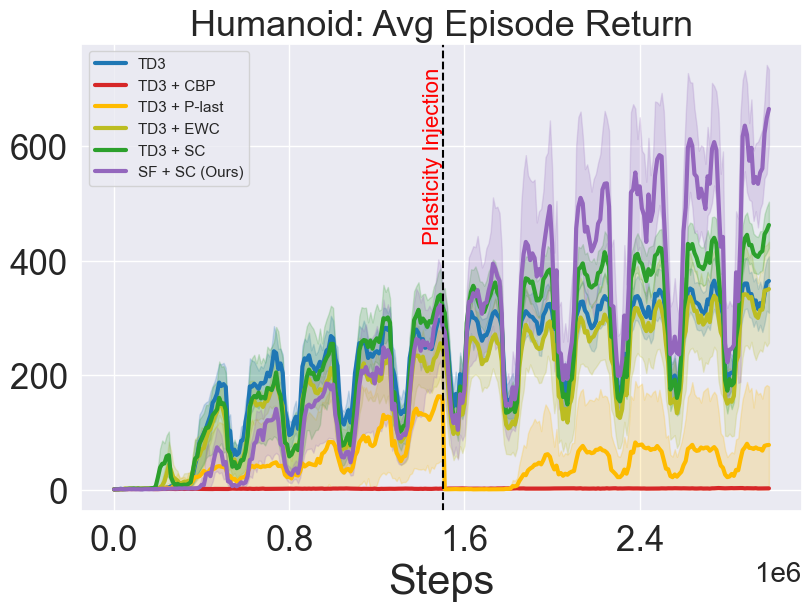

In [65]:
# Plot for Plasticity-Stability Analysis

from matplotlib.ticker import MaxNLocator, LogLocator
plt.close()
fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg"]],
    label=agents_new_names["ddpg"],
    color=color_code[agents_new_names["ddpg"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_continual_backprop"]],
    label=agents_new_names["ddpg_continual_backprop"],
    color=color_code[agents_new_names["ddpg_continual_backprop"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
)


sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_plasticity_injection_last_layer"]],
    label=agents_new_names["ddpg_plasticity_injection_last_layer"],
    color=color_code[agents_new_names["ddpg_plasticity_injection_last_layer"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_online_ewc"]],
    label=agents_new_names["ddpg_online_ewc"],
    color=color_code[agents_new_names["ddpg_online_ewc"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_beakers_params_continuous"]],
    label=agents_new_names["ddpg_beakers_params_continuous"],
    color=color_code[agents_new_names["ddpg_beakers_params_continuous"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params"]],
    label=agents_new_names["sf_simple_beakers_params"],
    color=color_code[agents_new_names["sf_simple_beakers_params"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
)

xline = 1500000
ymin, ymax = ax.get_ylim()

ax.axvline(x=xline, color="black", linestyle="--", linewidth=1.5)
ax.text(
    xline,                      # x position (same as line)
    ymin + 0.95* (ymax - ymin),   # 40% above the bottom,
    "Plasticity Injection",
    rotation=90,                # vertical text
    color="red",
    ha="right", va="top",       # horizontal/vertical alignment
    fontsize=16
)

plt.title("Humanoid: Avg Episode Return", fontsize=26)
plt.xlabel("Steps", fontsize=30)
plt.ylabel("", fontsize=30)
# plt.legend(loc="upper left", fontsize=16, ncol=1)
# plt.legend().set_visible(False)
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
ax.xaxis.get_offset_text().set_fontsize(20)
plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=5))
plt.gca().xaxis.set_major_locator(MaxNLocator(nbins=5))

filename = "plasticity_stability_analysis_with_sf_avg_episode_return_" + domain + "_" + cfg.mode
fig.savefig(filename + ".pdf")
plt.show()


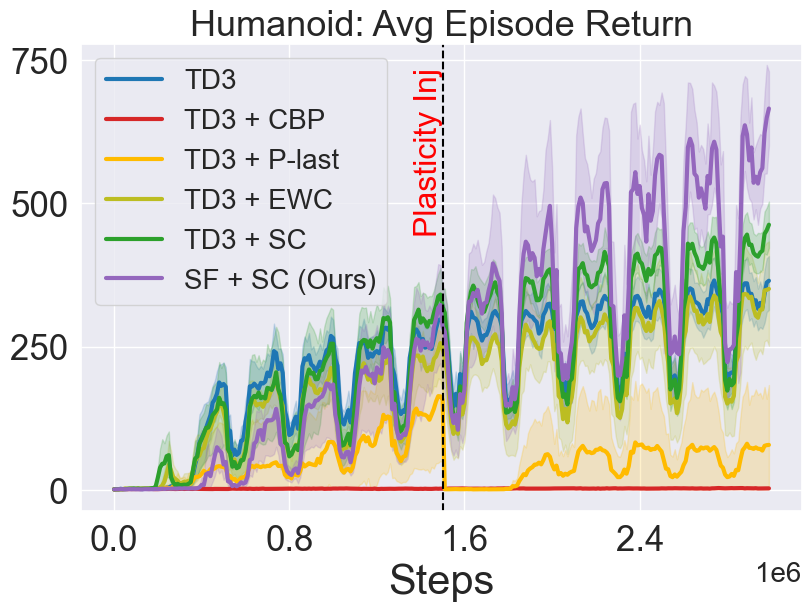

In [66]:
# Plot for Plasticity-Stability Analysis

from matplotlib.ticker import MaxNLocator, LogLocator
plt.close()
fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg"]],
    label=agents_new_names["ddpg"],
    color=color_code[agents_new_names["ddpg"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_continual_backprop"]],
    label=agents_new_names["ddpg_continual_backprop"],
    color=color_code[agents_new_names["ddpg_continual_backprop"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
)


sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_plasticity_injection_last_layer"]],
    label=agents_new_names["ddpg_plasticity_injection_last_layer"],
    color=color_code[agents_new_names["ddpg_plasticity_injection_last_layer"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_online_ewc"]],
    label=agents_new_names["ddpg_online_ewc"],
    color=color_code[agents_new_names["ddpg_online_ewc"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
)

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["ddpg_beakers_params_continuous"]],
    label=agents_new_names["ddpg_beakers_params_continuous"],
    color=color_code[agents_new_names["ddpg_beakers_params_continuous"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
)

# sns.lineplot(
#     x="eval/step",
#     y="eval/episode_reward",
#     data=runs_df[runs_df["agent_name"] == agents_new_names["sf_online_ewc"]],
#     label=agents_new_names["sf_online_ewc"],
#     color=color_code[agents_new_names["sf_online_ewc"]],
#     linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
# )

sns.lineplot(
    x="eval/step",
    y="eval/episode_reward",
    data=runs_df[runs_df["agent_name"] == agents_new_names["sf_simple_beakers_params"]],
    label=agents_new_names["sf_simple_beakers_params"],
    color=color_code[agents_new_names["sf_simple_beakers_params"]],
    linewidth=3,  # use this value if there are 3 plots in one row. Else use 5
)

xline = 1500000
ymin, ymax = ax.get_ylim()

ax.axvline(x=xline, color="black", linestyle="--", linewidth=1.5)
ax.text(
    xline,                      # x position (same as line)
    ymin + 0.95* (ymax - ymin),   # 40% above the bottom,
    "Plasticity Inj",
    rotation=90,                # vertical text
    color="red",
    ha="right", va="top",       # horizontal/vertical alignment
    fontsize=23
)

plt.title("Humanoid: Avg Episode Return", fontsize=26)
plt.xlabel("Steps", fontsize=30)
plt.ylabel("", fontsize=30)
plt.legend(loc="upper left", fontsize=20, ncol=1)
# plt.legend().set_visible(False)
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
ax.xaxis.get_offset_text().set_fontsize(20)
plt.gca().xaxis.set_major_locator(MaxNLocator(nbins=5))
plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=4))

filename = "synaptic_consolidation_with_sf_avg_episode_return_" + domain + "_" + cfg.mode
fig.savefig(filename + ".pdf")
plt.show()
